# Common Voice 23.0 Dataset Preparation for Fine-tuning of Open-source ASR model

This notebook preprocesses the [Common Voice 23.0 Uzbek dataset](https://datacollective.mozillafoundation.org/datasets/cmflnuzw7fd2f0vzknodytok4) for fine-tuning Whisper small speech recognition model. You can find more information about the structure of the dataset [here](https://github.com/common-voice/cv-dataset). The workflow consists of several key stages:
1. Data Loading & Consolidation
2. Data Cleaning & Enrichment
3. Dataset Analysis (dataset plotting and calculate speaker trust scores)
4. Strategic Sampling for Quality Control (by Google SPT)
5. Audio Preprocessing & Quality Validation
6. Audio-Transcription Alignment Quality Check (with Google SPT & Manual Review)

## Data Loading & Consolidation

- Loads train/dev/test splits from TSV files
- Merges additional validated recordings not in official splits
- Combines all data sources into a unified dataset

In [1]:
import os

import pandas as pd
from tqdm import tqdm

SEED = 137
DATASET_DIR = "../datasets/mcv-scripted-uz-v23.0/cv-corpus-23.0-2025-09-05/uz"
CUSTOM_VALIDATED_CSV_PATH = os.path.join(DATASET_DIR, "custom_validated.csv")
ALL_DATA_CSV_PATH = os.path.join(DATASET_DIR, "all_data.csv")
SAMPLED_RECORDINGS_PATH = os.path.join(DATASET_DIR, "sampled_recordings.csv")
NEW_SAMPLED_RECORDINGS_PATH = os.path.join(DATASET_DIR, "new_sampled_recordings.csv")
FINAL_SAMPLED_RECORDINGS_PATH = os.path.join(DATASET_DIR, "final_sampled_recordings.csv")
PROCESSED_AUDIO_STATS_PATH = os.path.join(DATASET_DIR, "processed_audio_stats.csv")
TRANSCRIPTION_RESULTS_OTHER_PATH = os.path.join(DATASET_DIR, "google_spt_transcriptions_other.csv")
TRANSCRIPTION_RESULTS_VALIDATED_PATH = os.path.join(DATASET_DIR, "google_spt_transcriptions_validated.csv")

COLUMNS_TO_DROP = ["sentence_domain", "accents", "variant", "locale", "segment"]

In [ ]:
import csv


def load_data_from_tsv(tsv_path: str) -> pd.DataFrame:
    """Load data from given tsv file with Common Voice specific configurations."""
    return pd.read_csv(
        tsv_path,
        sep="\t",
        quoting=csv.QUOTE_NONE,
        # Important: Common Voice doesn't use quotes at all (yet, pandas default quoting is csv.QUOTE_MINIMAL)
        dtype={"accents": str},
        low_memory=False,
        # Fix the mixed type warning
    )

In [3]:
# Load and combine split data (train.tsv, dev.tsv, test.tsv)
splits = []
for split_name in ["train", "dev", "test"]:
    split_tsv_file = os.path.join(DATASET_DIR, f"{split_name}.tsv")
    df = load_data_from_tsv(split_tsv_file)
    df["type"] = split_name
    splits.append(df)

combined_df = pd.concat(splits, ignore_index=True)

# Load additional validated data that's not already in the custom validated set
validated_df = load_data_from_tsv(os.path.join(DATASET_DIR, "validated.tsv"))
additional_validated_df = validated_df[~validated_df["path"].isin(combined_df["path"])].copy()

# Add additional data to train set
additional_validated_df["type"] = "train"
custom_validated_df = pd.concat([combined_df, additional_validated_df], ignore_index=True)
print(f"Total number of validated entries: {len(custom_validated_df)}")

print(custom_validated_df.info())

# Some speakers have inconsistent age and gender information (sometimes set, sometimes NaN)
custom_validated_df.groupby(["client_id", "gender", "age"], dropna=False).agg({"client_id": "count"})

Total number of validated entries: 87103
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87103 entries, 0 to 87102
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   client_id        87103 non-null  object 
 1   path             87103 non-null  object 
 2   sentence_id      87103 non-null  object 
 3   sentence         87103 non-null  object 
 4   sentence_domain  0 non-null      float64
 5   up_votes         87103 non-null  int64  
 6   down_votes       87103 non-null  int64  
 7   age              47537 non-null  object 
 8   gender           48096 non-null  object 
 9   accents          743 non-null    object 
 10  variant          0 non-null      float64
 11  locale           87103 non-null  object 
 12  segment          0 non-null      float64
 13  type             87103 non-null  object 
dtypes: float64(3), int64(2), object(9)
memory usage: 9.3+ MB
None


client_id
client_id                                          gender         age                
0003767547f3b2fb06d9844f394d8ba7da4fcafbf283a6a... NaN            NaN               1
005b4b58ad4aae5d9a230358c1baaf937a84b17d4d90c71... NaN            NaN              23
007051a4439cd86e313040a2060e49ad724e7bc22228204... NaN            NaN               5
007792d9631b713ae29c51b11f50a6a881f2df62cf6f821... male_masculine twenties         83
                                                   NaN            NaN               5
...                                                                               ...
fdf11d59bf39416f881e32e5d763daec205c14992f64070... NaN            NaN               1
fe62c8d956adf6156df94703f086eefd7a2fc2f5d803f1e... NaN            NaN               2
fea9a299dcdc9bf14918a911102ebc85b6923f437acc461... NaN            NaN               4
fed2f2355b3509d693c77b7dc45cf4951961902f426bf7a... male_masculine twenties          5
ffdd1f0aeb20970880a508c798b98aab8dad09106cfdb45... NaN            NaN              65

[1601 rows x 1 columns]

## Data Cleaning & Enrichment

- Removes unnecessary columns (accents, locale, segments, etc.)
- Adds clip durations and word counts
- Normalizes Uzbek transcription text
- Fills missing speaker demographics (age/gender) by forward/backward filling per speaker

In [4]:
import scripts.uzbek_text_normalizer as utn


def load_clip_durations(dataset_dir: str) -> dict:
    """Load clip durations and return as a dictionary."""
    clip_durations_df = pd.read_csv(os.path.join(dataset_dir, "clip_durations.tsv"), sep="\t")
    clip_durations_df["duration"] = clip_durations_df["duration[ms]"] / 1000
    clip_durations_df.drop(columns=["duration[ms]"], inplace=True)

    return (
        clip_durations_df
        .set_index("clip")["duration"]
        .to_dict()
    )


def fill_known_gender_age_columns(df: pd.DataFrame):
    """
    Fill known gender and age values from each speaker.

    Some speakers have inconsistent age and gender information (sometimes set, sometimes NaN)
    """
    df["gender"] = df["gender"].astype("string")
    df["age"] = df["age"].astype("string")  # For silence warning

    df[["gender", "age"]] = df.groupby("client_id")[["gender", "age"]].transform(
        lambda x: x.ffill().bfill())

    return df


def prepare_final_data(df: pd.DataFrame, dataset_dir: str, output_csv_file_name: str = "output.csv") -> pd.DataFrame:
    """
    Drop unnecessary columns, add clip durations and word count columns,
    normalize transcription text, fill known gender and age values per speaker,
    save the result to csv file.
    """
    # Remove unnecessary columns
    df.drop(
        columns=COLUMNS_TO_DROP,
        inplace=True,
    )

    # Remove rows with sentence is None or whitespace only
    df = df[df["sentence"].notna() & (df["sentence"].str.strip() != '')]

    # Add clip durations
    clip_duration_dict = load_clip_durations(dataset_dir)
    df["duration"] = df["path"].map(clip_duration_dict)

    # Normalize transcription text
    df["sentence"] = df["sentence"].apply(utn.normalize_text)

    # Add word count
    df["word_count"] = df["sentence"].str.split().str.len()

    # Fill missing gender and age per client_id
    df = fill_known_gender_age_columns(df)

    # Save result
    output_csv_path = os.path.join(dataset_dir, output_csv_file_name)
    print(f"Saving to {output_csv_path}...")
    df.to_csv(output_csv_path, index_label="id")

    print(f"✓ Processing complete. Total records: {len(df)}")
    return df


# Final data preparation (drop and add columns, normalize transcription text, save the results to csv)
prepare_final_data(custom_validated_df, DATASET_DIR, output_csv_file_name="custom_validated.csv")

Saving to ../datasets/mcv-scripted-uz-v23.0/cv-corpus-23.0-2025-09-05/uz/custom_validated.csv...
✓ Processing complete. Total records: 87103


,client_id,path,sentence_id,sentence,up_votes,down_votes,age,gender,type,duration,word_count
0,2160561702bac0e2048d2dc79810c2d8a6e6942a6dcac8...,common_voice_uz_28907218.mp3,bc07db8b7a00a0b99d7c0ef267d1de330e807c9810eef6...,Bugun ertalab Gyotenikiga taklifnoma oldim.,2,0,twenties,male_masculine,train,4.788,5
1,2160561702bac0e2048d2dc79810c2d8a6e6942a6dcac8...,common_voice_uz_28907221.mp3,a6530f96b764bd5571b024ea38e448df2deae123e522f0...,Uning badiiy tasvir imkoniyatlarini rivojlanti...,2,0,twenties,male_masculine,train,5.076,5
2,2160561702bac0e2048d2dc79810c2d8a6e6942a6dcac8...,common_voice_uz_28907226.mp3,c1a227e11d003ffe07a9b86850637ae0e4adfb1351ae72...,Udan ko'ra balandroq joy bor.,2,1,twenties,male_masculine,train,4.140,5
3,2160561702bac0e2048d2dc79810c2d8a6e6942a6dcac8...,common_voice_uz_28907243.mp3,bb64eb96e0ce5f555cc8d3420687b9b4079165003999ed...,Bu jumlada fig'oni falakka chiqib birikmasi ib...,2,1,twenties,male_masculine,train,7.560,12
4,2160561702bac0e2048d2dc79810c2d8a6e6942a6dcac8...,common_voice_uz_28907245.mp3,85a5fea3c41d39bcfe0ea6c75b1a1ea7fd9395aeed064b...,Bundan tashqari puxta jamlangan kutubxona bor.,2,1,twenties,male_masculine,train,5.436,6
...,...,...,...,...,...,...,...,...,...,...,...
87098,30fd02023d452dbd8d83510cf487aabca11a7138c6245b...,common_voice_uz_30299258.mp3,c6db057a9f4390f5eba23152931ed21106e23267701694...,Ikki,2,0,twenties,female_feminine,train,1.548,1
87099,30fd02023d452dbd8d83510cf487aabca11a7138c6245b...,common_voice_uz_30299279.mp3,c70f4b9db0b02db22056d4ef5a1c8cf9eb5c6c82ea0499...,U boshqa kasb etagini tutsin.,2,0,twenties,female_feminine,train,2.736,5
87100,30fd02023d452dbd8d83510cf487aabca11a7138c6245b...,common_voice_uz_30299677.mp3,c8f9a9bdaf43fed1bbd5db7c049ecce6601520eb54cc53...,Quyosh ham tolib oyog'i,2,0,twenties,female_feminine,train,2.340,4
87101,30fd02023d452dbd8d83510cf487aabca11a7138c6245b...,common_voice_uz_30299721.mp3,c8bc1507705991a9552dc11f3e507f984161a35ffb1bb5...,"Sizga, olavering. Chakkangiz og'riganda kerak ...",2,0,twenties,female_feminine,train,3.960,6


In [5]:
custom_validated_df = pd.read_csv(CUSTOM_VALIDATED_CSV_PATH, index_col="id")

# Compare the results against previous inconsistent age and gender information
print(custom_validated_df.info())
custom_validated_df.groupby(["client_id", "gender", "age"], dropna=False).agg({"client_id": "count"})

<class 'pandas.core.frame.DataFrame'>
Index: 87103 entries, 0 to 87102
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   client_id    87103 non-null  object 
 1   path         87103 non-null  object 
 2   sentence_id  87103 non-null  object 
 3   sentence     87103 non-null  object 
 4   up_votes     87103 non-null  int64  
 5   down_votes   87103 non-null  int64  
 6   age          79989 non-null  object 
 7   gender       80674 non-null  object 
 8   type         87103 non-null  object 
 9   duration     87103 non-null  float64
 10  word_count   87103 non-null  int64  
dtypes: float64(1), int64(3), object(7)
memory usage: 8.0+ MB
None


,,,client_id
client_id,gender,age,
0003767547f3b2fb06d9844f394d8ba7da4fcafbf283a6ae4fcc072770701d81380c5a5666eadf5b87dd678972e27939b6dbb73a4fa515fae440d2a45d0ae940,NaN,NaN,1
005b4b58ad4aae5d9a230358c1baaf937a84b17d4d90c71e1128c1373febfe1f2114b652b8d4221a6c565c015a23cd1761dfdcf4196b05e01632ca43e281b3f0,NaN,NaN,23
007051a4439cd86e313040a2060e49ad724e7bc22228204d2bca3ae178a1bbffc45478b5a9e7d073cfd8af761112fb4270029f8013c0c27c467629d63f64381d,NaN,NaN,5
007792d9631b713ae29c51b11f50a6a881f2df62cf6f821b10aeb46b523a5f443554ab36121a843938d1b748a87068550e40c263143ffa31bb3a6e337a803150,male_masculine,twenties,88
008a642a3f1b0f750c3bec478088f666ab9929557c3d0e834c564adeb7d65b3256b78c7a1e4d09822373bbb47435c5abf7f244b881c4411b28d5af928db3deb3,NaN,NaN,1
...,...,...,...
fdf11d59bf39416f881e32e5d763daec205c14992f640702da21b0138e74c09bf9d08a9254ade92dd51e1b39048093f81f35ae31a02cdb8b9ec4c9308dd4caea,NaN,NaN,1
fe62c8d956adf6156df94703f086eefd7a2fc2f5d803f1e8096d357569bf72a6daf2813d00151f73f8cea8b3fa0c9d95f9aecfd9e4f46e7cfdcc9258aefdc499,NaN,NaN,2
fea9a299dcdc9bf14918a911102ebc85b6923f437acc461150be644cbdfde1efde2e130bada237c0f216aa693ad72c2cf9308408102c7f9a31d470315be352b0,NaN,NaN,4


In [6]:
print(custom_validated_df.info())
print(custom_validated_df.describe())
print("\nFirst few rows:")
custom_validated_df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 87103 entries, 0 to 87102
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   client_id    87103 non-null  object 
 1   path         87103 non-null  object 
 2   sentence_id  87103 non-null  object 
 3   sentence     87103 non-null  object 
 4   up_votes     87103 non-null  int64  
 5   down_votes   87103 non-null  int64  
 6   age          79989 non-null  object 
 7   gender       80674 non-null  object 
 8   type         87103 non-null  object 
 9   duration     87103 non-null  float64
 10  word_count   87103 non-null  int64  
dtypes: float64(1), int64(3), object(7)
memory usage: 8.0+ MB
None
           up_votes    down_votes      duration    word_count
count  87103.000000  87103.000000  87103.000000  87103.000000
mean       2.015602      0.185034      4.396574      6.269049
std        0.153555      0.390950      1.539892      2.643489
min        2.000000      0.000000  

,client_id,path,sentence_id,sentence,up_votes,down_votes,age,gender,type,duration,word_count
id,,,,,,,,,,,
0,2160561702bac0e2048d2dc79810c2d8a6e6942a6dcac8...,common_voice_uz_28907218.mp3,bc07db8b7a00a0b99d7c0ef267d1de330e807c9810eef6...,Bugun ertalab Gyotenikiga taklifnoma oldim.,2,0,twenties,male_masculine,train,4.788,5
1,2160561702bac0e2048d2dc79810c2d8a6e6942a6dcac8...,common_voice_uz_28907221.mp3,a6530f96b764bd5571b024ea38e448df2deae123e522f0...,Uning badiiy tasvir imkoniyatlarini rivojlanti...,2,0,twenties,male_masculine,train,5.076,5
2,2160561702bac0e2048d2dc79810c2d8a6e6942a6dcac8...,common_voice_uz_28907226.mp3,c1a227e11d003ffe07a9b86850637ae0e4adfb1351ae72...,Udan ko'ra balandroq joy bor.,2,1,twenties,male_masculine,train,4.140,5
3,2160561702bac0e2048d2dc79810c2d8a6e6942a6dcac8...,common_voice_uz_28907243.mp3,bb64eb96e0ce5f555cc8d3420687b9b4079165003999ed...,Bu jumlada fig'oni falakka chiqib birikmasi ib...,2,1,twenties,male_masculine,train,7.560,12
4,2160561702bac0e2048d2dc79810c2d8a6e6942a6dcac8...,common_voice_uz_28907245.mp3,85a5fea3c41d39bcfe0ea6c75b1a1ea7fd9395aeed064b...,Bundan tashqari puxta jamlangan kutubxona bor.,2,1,twenties,male_masculine,train,5.436,6


In [7]:
other_df = load_data_from_tsv(os.path.join(DATASET_DIR, "other.tsv"))
other_df["type"] = "other"
other_df = prepare_final_data(other_df, DATASET_DIR, "other.csv")

invalidated_df = load_data_from_tsv(os.path.join(DATASET_DIR, "invalidated.tsv"))
invalidated_df["type"] = "invalidated"
invalidated_df = prepare_final_data(invalidated_df, DATASET_DIR, "invalidated.csv")

all_data_df = pd.concat([custom_validated_df, other_df, invalidated_df], ignore_index=True)
print(f"Saving to {ALL_DATA_CSV_PATH}...")
all_data_df.to_csv(ALL_DATA_CSV_PATH, index_label="id")
print(f"✓ Processing complete. Total records: {len(all_data_df)}")
all_data_df.info()

Saving to ../datasets/mcv-scripted-uz-v23.0/cv-corpus-23.0-2025-09-05/uz/other.csv...
✓ Processing complete. Total records: 128485


/tmp/ipykernel_25640/3248158290.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["duration"] = df["path"].map(clip_duration_dict)
/tmp/ipykernel_25640/3248158290.py:52: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["sentence"] = df["sentence"].apply(utn.normalize_text)
/tmp/ipykernel_25640/3248158290.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https:

Saving to ../datasets/mcv-scripted-uz-v23.0/cv-corpus-23.0-2025-09-05/uz/invalidated.csv...
✓ Processing complete. Total records: 14116
Saving to ../datasets/mcv-scripted-uz-v23.0/cv-corpus-23.0-2025-09-05/uz/all_data.csv...
✓ Processing complete. Total records: 229704
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 229704 entries, 0 to 229703
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   client_id    229704 non-null  object 
 1   path         229704 non-null  object 
 2   sentence_id  229704 non-null  object 
 3   sentence     229704 non-null  object 
 4   up_votes     229704 non-null  int64  
 5   down_votes   229704 non-null  int64  
 6   age          193238 non-null  object 
 7   gender       194395 non-null  object 
 8   type         229704 non-null  object 
 9   duration     229704 non-null  float64
 10  word_count   229704 non-null  int64  
dtypes: float64(1), int64(3), object(7)
memory usage: 19.3+ 

## Dataset Analysis

- Generates distribution plots (duration, gender, demographics)
- Calculates speaker trust scores based on up/down votes
- Analyzes speaker recording patterns and quality metrics

### Dataset Plotting

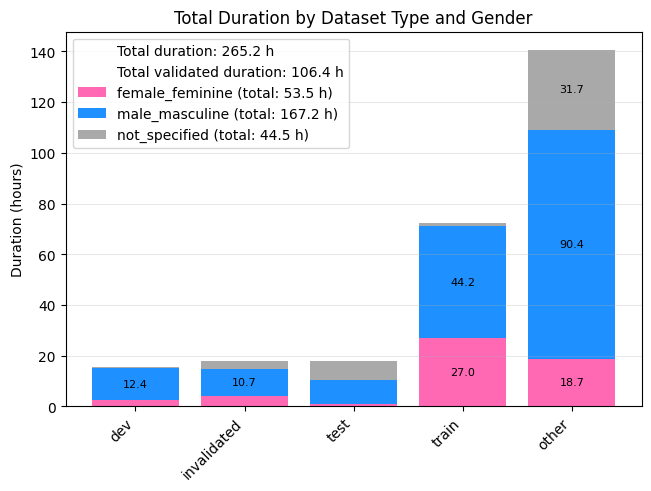

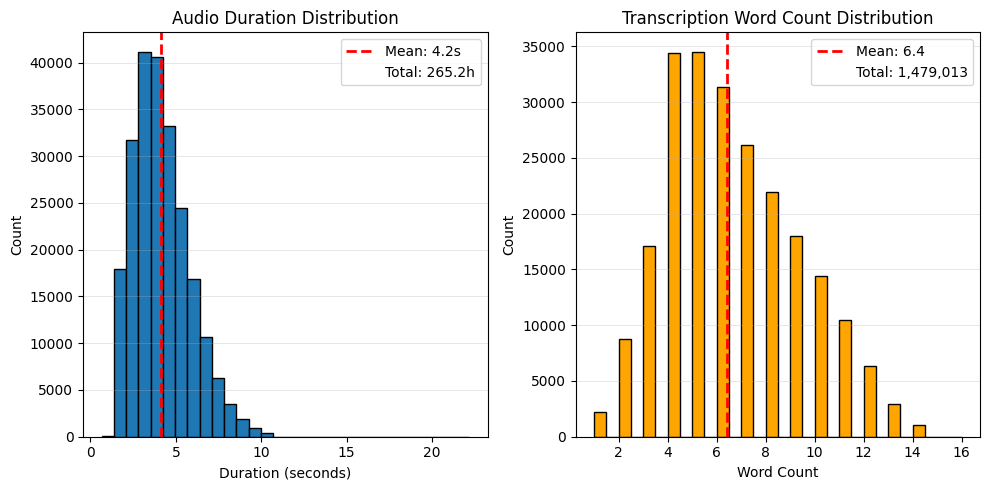

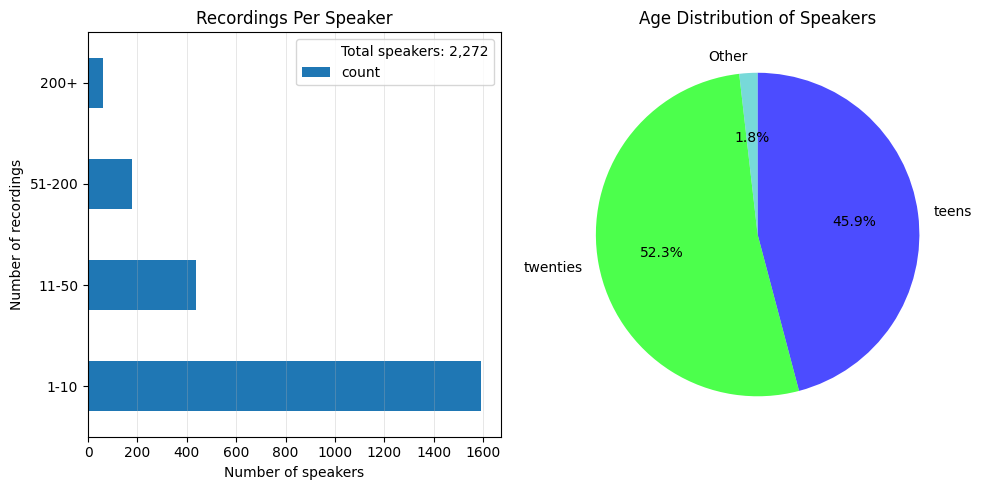

The custom validated dataset includes 87,103 samples. Among them, 80.9% have a positive difference of 2, while 18.2% have a difference of 1.


true_votes
2    70424
1    15863
3      558
4      238
6       11
5        9
Name: count, dtype: int64

In [8]:
from scripts.dataset_plotting import plot_distribution_graphs, plot_dataset_type_gender_distribution, \
    plot_demographic_statistics

plot_dataset_type_gender_distribution(all_data_df)
plot_distribution_graphs(all_data_df)
plot_demographic_statistics(all_data_df)

# Compute true votes (up_votes - down_votes) and its distribution
custom_validated_df = pd.read_csv(CUSTOM_VALIDATED_CSV_PATH, index_col="id")
custom_validated_df["true_votes"] = (
        custom_validated_df["up_votes"] - custom_validated_df["down_votes"]
)

# Free up memory
del all_data_df, other_df, invalidated_df

total_custom_validated_entries = len(custom_validated_df)
true_votes_count = custom_validated_df["true_votes"].value_counts()
print(
    f"The custom validated dataset includes {total_custom_validated_entries:,} samples. Among them, {100 * true_votes_count.iloc[0] / total_custom_validated_entries:.1f}% have a positive difference of {true_votes_count.keys()[0]}, while {100 * true_votes_count.iloc[1] / total_custom_validated_entries:.1f}% have a difference of {true_votes_count.keys()[1]}.")
true_votes_count

### Calculate Speaker Trust Scores

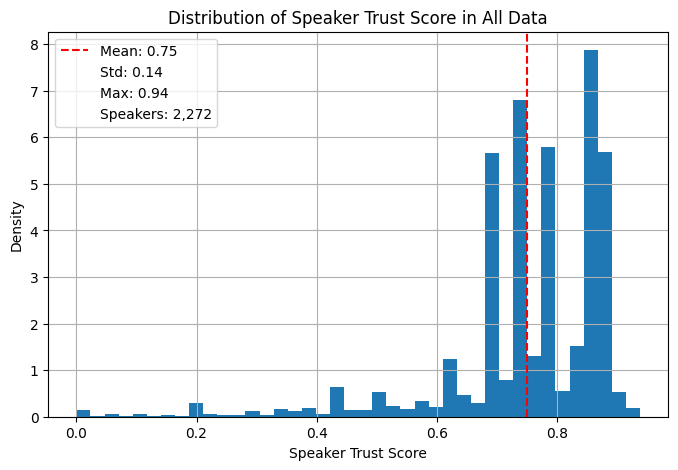

,,up_votes,down_votes,num_recordings
client_id,speaker_trust_score,,,
63c30d8f047df7491379e2bcb6ae54864b35cf1cbd55fd9b0d12a460ea26eb690a699dc540b14b171449ca8d71da92a95ffd22eeef92e04aa18a08c196cd7e43,0.9379,434,18,224
f763d1835e4436a3a85f271bf404cdbcf23f9b9c6f7d4d76772ab58246f52f10b6ea6697e454caa590e7fc49f2d47db547a0d584303e1f113346ab93378d5ef4,0.9375,806,39,404
b5e51f0ffdf226e4c74bc2037bbd9d5a79dbf9660e880f6eb6216f1f9937d172dfda25db5ba2006f18033b83be81e8abf39e0909186eeb7acf41c510dda91d5e,0.9367,109,2,58
44c15c0f726ba78cb2a2f545eebe60e36e997c805e44d1e3672a2e0152f91a9b10a38873c074b7e7efec7d28802e98d0a8ec81e2ba47e9aa8c869a2e68f8fb97,0.9236,126,4,63
b4968971e35c5a65c94480ab31561c7b12ae289bb23e1dade0997e13137c92812e130113f257dc7cf9562bfa11b30a704dfed02cf3fe7d58848214c2cbf5fe34,0.9224,68,1,35
...,...,...,...,...
f679bce4fb519e51f14104a265400e0eea6eafe454420aa7514cf143eded37955ffa2938e608876b200322eef79a3497251670198112e643b0c2eeb3cc2cbecb,0.0000,0,10,5
79295ce47f1be5826e279f29f0779a366a035e8bf77ea3dfdb116a347b8bae95919fb7eac84ea263eab270e9ab00fcffce82a432f3961f1e33330c60bea51857,0.0000,0,1,3
930551688e12393b5a04054f2a877a69c5d347fffed64b1a666f867a22b79595382dc164069e79c516fddd5ed0f0ace394c361ede18b953dec26c23d16cd63f0,0.0000,0,1,10


In [9]:
import scripts.speaker_trust_score
from scripts.dataset_plotting import plot_speaker_trust_score_distribution

all_data_df = pd.read_csv(ALL_DATA_CSV_PATH, index_col="id")
all_data_df = scripts.speaker_trust_score.trust_score(all_data_df)
all_data_df.to_csv(ALL_DATA_CSV_PATH)

plot_speaker_trust_score_distribution(all_data_df, data_frame_title="All Data")

grouped = (
    all_data_df
    .groupby(["client_id", "speaker_trust_score"])
    .agg({
        "up_votes": "sum",
        "down_votes": "sum",
        "client_id": "count",  # counts recordings per speaker
    })
    .rename(columns={"client_id": "num_recordings"})
)
grouped.sort_values(
    by="speaker_trust_score",
    ascending=False
)

## Strategic Sampling for Quality Control (by Google SPT)

- Extracts ~3,600 recordings (8.2 hours audios) from non-validated ("other") set to be checked the alignment of audio-transcription by Google's Speech-to-Text model
- Targets medium-trust speakers (0.30-0.75 score) with longer recordings (3-15s)
- Samples stratified by duration: 300 short (3-6s), 800 medium (6-8s), all long (8-15s)
- Total: ~2-3 hours of audio for manual validation

In [10]:
other_df = all_data_df[all_data_df["type"] == "other"].reset_index(drop=True)
other_df.index.name = "id"

other_df_grouped = (
    other_df
    .groupby(["client_id", "speaker_trust_score"])
    .agg({
        "up_votes": "sum",
        "down_votes": "sum",
        "client_id": "count",  # counts recordings per speaker
    })
    .rename(columns={"client_id": "num_recordings"})
).reset_index()

speakers_to_check = other_df_grouped[
    (other_df_grouped["speaker_trust_score"] < 0.75) &
    (other_df_grouped["speaker_trust_score"] > 0.30)
    ]

speakers_to_check = speakers_to_check.sort_values(
    by="num_recordings", ascending=False
).head(300)
speakers_to_check

,client_id,speaker_trust_score,up_votes,down_votes,num_recordings
922,b7808eea20000dd73de504f3d1b545ee8e39025baca405...,0.6816,5097,3731,21593
945,bc69c744bf0f8464394b0554f6d87cc8e1bb9286bf3d13...,0.7333,4494,4189,18740
895,b303b536e41d001670724c7f7902bae04eb218dcb714e1...,0.6494,205,90,980
939,ba6259effb0707163a6a7c2440301ffc466461192eea3a...,0.6181,145,65,581
1002,c83c69afe7f26b08b118c14ca76dfe812177d8acca62ea...,0.7352,92,23,456
...,...,...,...,...,...
121,1ab81b39ba79e347dc49dc60fecc2401504c190abe9ab4...,0.3755,2,1,9
1037,d0c3874f59c5fd3de9294e8093f984a7eac9eb1ea0261c...,0.6097,4,0,9
530,6def659c15a16f52b60189ed75ced6474cc37e98aebabb...,0.7256,0,0,9
352,4b8db9ad0bc8578ff93dc23cb847913a59ee13ee05e4e3...,0.5000,0,0,9


In [11]:
# Filter only these top speakers
speaker_ids = speakers_to_check["client_id"].tolist()
top_speakers_to_check = other_df["client_id"].isin(speaker_ids)

# Filter longer duration recordings
short_audios = (other_df["duration"] >= 3) & (other_df["duration"] < 6)
medium_audios = (other_df["duration"] >= 6) & (other_df["duration"] < 8)
long_audios = (other_df["duration"] >= 8) & (other_df["duration"] <= 15)

short_recordings = (
    other_df[short_audios & top_speakers_to_check]
    .groupby("client_id")
    .apply(lambda x: x.sample(min(len(x), 30)), include_groups=False)  # Maximum up to 30 recordings per speaker
    .reset_index(level=0)
).sample(300, weights="duration", random_state=SEED)
print(f"short_recordings: \n{short_recordings["client_id"].describe()}")

medium_recordings = (
    other_df[medium_audios & top_speakers_to_check]
    .groupby("client_id")
    .apply(lambda x: x.sample(min(len(x), 50)), include_groups=False)  # Maximum up to 50 recordings per speaker
    .reset_index(level=0)
).sample(800, weights="duration", random_state=SEED)
print(f"\nmedium_recordings: \n{medium_recordings["client_id"].describe()}")

long_recordings = other_df[long_audios]
print(f"\nlong_recordings: \n{long_recordings["client_id"].describe()}")

sampled_recordings_df = pd.concat([short_recordings, medium_recordings, long_recordings]).sort_index()
print(f"\nsampled_recordings: \n{sampled_recordings_df["client_id"].describe()}")

total_sampled_duration = sampled_recordings_df["duration"].sum(axis=0) / 3600
print(f"\nTotal sampled duration: {total_sampled_duration:,.2f}h")

sampled_recordings_df["type"] = "other"
sampled_recordings_df.to_csv(SAMPLED_RECORDINGS_PATH)
sampled_recordings_df

short_recordings: 
count                                                   300
unique                                                  178
top       e0178b2ed6d002603bbe4efaec2daa398ebbf7a48e4bac...
freq                                                      6
Name: client_id, dtype: object

medium_recordings: 
count                                                   800
unique                                                  233
top       b7808eea20000dd73de504f3d1b545ee8e39025baca405...
freq                                                     17
Name: client_id, dtype: object

long_recordings: 
count                                                  2562
unique                                                  630
top       30fd02023d452dbd8d83510cf487aabca11a7138c6245b...
freq                                                    225
Name: client_id, dtype: object

sampled_recordings: 
count                                                  3662
unique                                        

,client_id,path,sentence_id,sentence,up_votes,down_votes,age,gender,type,duration,word_count,speaker_trust_score
id,,,,,,,,,,,,
22,f472b9041ed520010f3057ec877359962118d70ab883b9...,common_voice_uz_29007503.mp3,66306770bc5bce055e622869d1c43fc98f6562a0dff39a...,Jonli va jonsiz narsalarni bildiruvchi boshqa ...,0,1,teens,male_masculine,other,9.360,10,0.0982
67,60d8d81ca356533bbfcd36f93ff734211cb2aa6b540cc5...,common_voice_uz_29055349.mp3,046d199aefc23554546a8ad4a5c6bd9fd309fac8d7da43...,Vaqt yoki dam olish vaqti adras ko'ylakni kiyi...,1,0,twenties,male_masculine,other,8.316,14,0.7509
71,60d8d81ca356533bbfcd36f93ff734211cb2aa6b540cc5...,common_voice_uz_29055365.mp3,06ec2fe357d58e6094c28646dda9d475d50ff7f17852fe...,"Mansab pillapoyalaridan ko'tarilganda, xalqqa ...",1,0,twenties,male_masculine,other,10.116,10,0.7509
115,60d8d81ca356533bbfcd36f93ff734211cb2aa6b540cc5...,common_voice_uz_29055855.mp3,01c755675baa7543cf02624ecfa6c5453c549ae1f4d314...,Hukumatning tepasidagi juda katta amaldorlarni...,1,0,twenties,male_masculine,other,9.720,14,0.7509
137,28f17a51e3d73a411606697113f170b2cf1e419c2c1768...,common_voice_uz_29056015.mp3,088aaf642080925ffdff5499e2e1aa54ad365a9d6798a8...,Davlat rahbari ijtimoiy-iqtisodiy islohotlarni...,1,0,twenties,female_feminine,other,9.540,12,0.7219
...,...,...,...,...,...,...,...,...,...,...,...,...
128465,2143e2fad4e7de42747b75f150a204a5c1192339ade7c2...,common_voice_uz_43495076.mp3,98e546f3059152120502451f9969dabb9e44cfe4190563...,Ronaldu ketgach uzoq vaqt bosim ostida o'ynadi...,0,0,NaN,NaN,other,5.616,8,0.5000
128467,99624694dd5079c29c4b955a58b0aeb8fe1ca6ade80916...,common_voice_uz_43506369.mp3,0013dd32881284bb0bedc22b601083eb3be468c3891da6...,Unda haqiqatni gapirishga izn bering,0,0,NaN,NaN,other,10.008,5,0.5000
128470,6f44c71af2e2d25da8099d59c8aa9de0331c654a57d40f...,common_voice_uz_43526807.mp3,97a970e52488c2421a375821ed9c82ecb1d4c948d30b02...,"Buni qarangki, Yoshlar ittifoqi shahar kengash...",0,0,twenties,male_masculine,other,9.396,14,0.6737


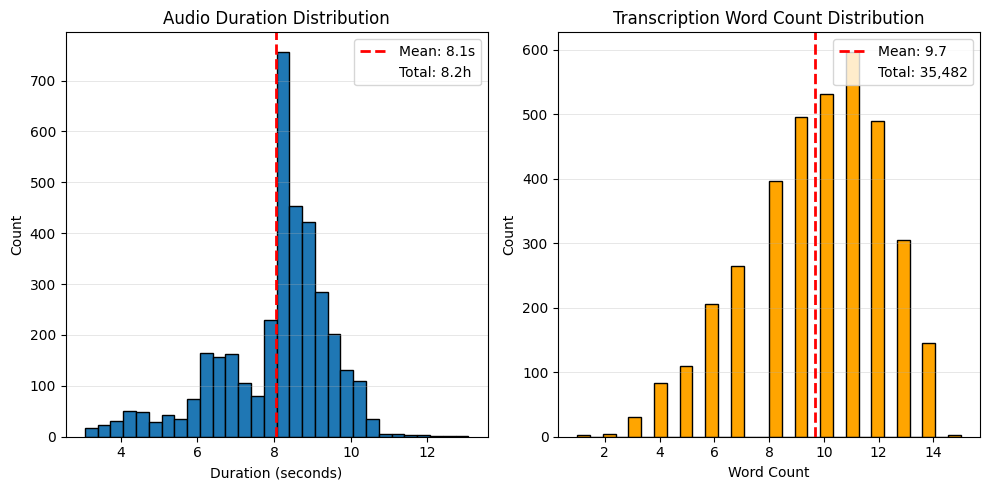

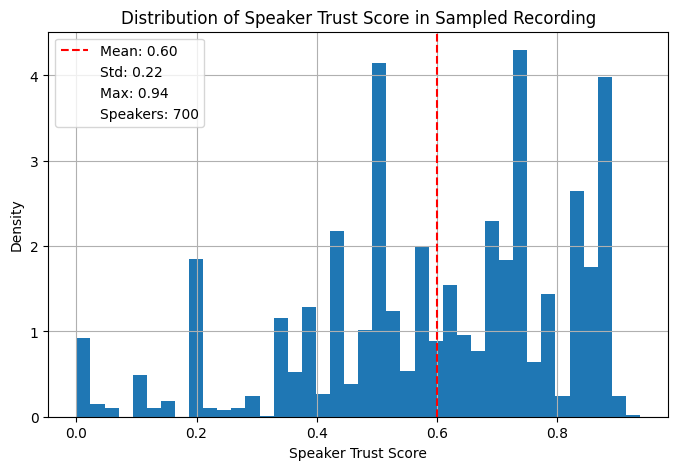

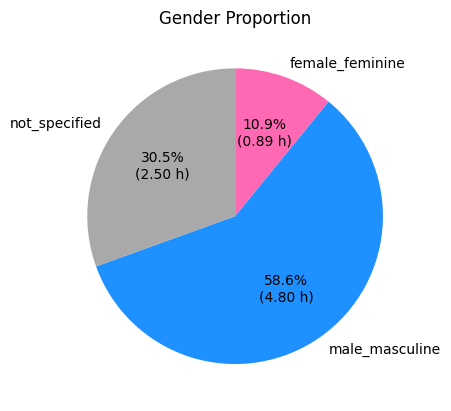

In [12]:
from scripts.dataset_plotting import plot_gender_pie_chart

plot_distribution_graphs(sampled_recordings_df)
plot_speaker_trust_score_distribution(sampled_recordings_df, data_frame_title="Sampled Recording")
plot_gender_pie_chart(sampled_recordings_df)

del other_df

## Audio Preprocessing & Quality Validation

- Performs two types of audio processing with all sampled recordings: 1) preserves original audio (only resamples to 16 kHz, converts to mono and WAV format); 2) applies same steps as above and followings as well:
    - Applies high-pass filter (80 Hz cutoff) to remove low-frequency noise
    - Removes leading/trailing silence (threshold: -45 dB, min: 1.3s)
    - Applies audio volume normalization (target RMS: -23 dB)
    - If required, applies soft limiting to prevent clipping (threshold: 0.95)
    - Creates audio specific statistics before and after audio processing to be reviewed
- Reviews audio preprocessing results with side-by-side comparisons
- Flags and removes recordings that became too short (<2s after silence removal)
- Down-votes suspicious recordings where excessive silence was detected

In [14]:
import scripts.audio_preprocessing as ap
import glob

sampled_recordings_df = pd.read_csv(SAMPLED_RECORDINGS_PATH, index_col="id")

sampled_original_recordings_directory = os.path.join(DATASET_DIR, "sampled_clips_original")
if not os.path.exists(sampled_original_recordings_directory):
    os.makedirs(sampled_original_recordings_directory)

# Extract sampled audios and standardize to 16 kHz
new_audio_extension = "wav"
for audio_path in tqdm(sampled_recordings_df["path"], desc="Processing files"):
    file_name, file_extension = os.path.splitext(audio_path)
    full_audio_path = os.path.join(DATASET_DIR, "clips", audio_path)
    path_to_save = os.path.join(sampled_original_recordings_directory, f"{file_name}.{new_audio_extension}")

    ap.resample_audio(full_audio_path, target_sr=16_000, save_path=path_to_save)

saved_recordings = glob.glob(f"{sampled_original_recordings_directory}/*.{new_audio_extension}")
assert len(sampled_recordings_df["path"].unique()) == len(saved_recordings)
print(f"Extracted {len(saved_recordings)} audios and resampled to 16 kHZ")

Processing files: 100%|██████████| 3662/3662 [00:16<00:00, 225.98it/s]

Extracted 3662 audios and resampled to 16 kHZ


In [15]:
from pathlib import Path
from scripts.audio_preprocessing import process_audio_file

stats = []
sampled_normalized_recording_directory = os.path.join(DATASET_DIR, "sampled_clips_normalized")
for audio_file_path in tqdm(saved_recordings, desc="Processing files"):
    audio_filename = Path(audio_file_path).name
    waveform, stat = process_audio_file(
        audio_file_path,
        save_path=os.path.join(sampled_normalized_recording_directory, audio_filename),
        normalize=True,
        target_rms_db=-23.0,
        apply_highpass=True,
        highpass_cutoff=80.0,
        remove_silences=True,
        silence_threshold_db=-45.0,
        min_silence_duration=1.3,
    )
    stats.append(stat)

processed_audio_stats_df = pd.DataFrame(stats)
processed_audio_stats_df

Processing files: 100%|██████████| 3662/3662 [01:01<00:00, 59.45it/s]


,input_audio_filename,original_rms_db,final_rms_db,original_duration,final_duration,reduced_duration,peak_amplitude,is_clipped
0,common_voice_uz_30252783.wav,-15.5385,-23.0988,8.208,8.208,0.000,0.3409,False
1,common_voice_uz_29671041.wav,-25.1509,-23.2657,9.756,9.756,0.000,0.6340,False
2,common_voice_uz_29200656.wav,-31.0495,-23.1830,9.180,4.600,4.580,0.5550,False
3,common_voice_uz_32263657.wav,-24.8811,-23.1562,10.440,9.440,1.000,0.5411,False
4,common_voice_uz_30277438.wav,-21.7607,-23.1022,9.180,9.180,0.000,0.4806,False
...,...,...,...,...,...,...,...,...
3657,common_voice_uz_33794448.wav,-18.0525,-23.1489,8.460,8.460,0.000,0.4358,False
3658,common_voice_uz_32380688.wav,-29.5770,-23.3818,8.280,7.220,1.060,0.7551,False
3659,common_voice_uz_30181075.wav,-16.6817,-23.1494,8.100,8.100,0.000,0.3952,False
3660,common_voice_uz_31930408.wav,-61.8767,-23.1018,8.460,0.500,7.960,0.5874,False


### Audio Pre-processing Manual Quality Validation

In [16]:
from IPython.display import HTML, display


def two_audio_columns(stats_dict, original_audios_directory, normalized_audios_directory):
    html = "<table>"
    for audio_filename, stat in stats_dict.items():
        html += "<tr>"
        html += f"<td style='padding:10px; vertical-align:top;'>"
        html += f"<audio controls><source src='{os.path.join(original_audios_directory, audio_filename)}' type='audio/wav'></audio>"
        html += f"<p>Original rms: {stat['original_rms_db']} dB | original duration: {stat['original_duration']}</p>"
        html += "</td>"

        html += f"<td style='padding:10px; vertical-align:top;'>"
        html += f"<audio controls><source src='{os.path.join(normalized_audios_directory, audio_filename)}' type='audio/wav'></audio>"
        html += f"<p>Normalized rms: {stat['final_rms_db']} dB | reduced duration: {stat['reduced_duration']} | <b>{audio_filename}</b></p>"
        html += "</td>"
        html += "</tr>"
    html += "</table>"
    display(HTML(html))


top_low_original_rms_dict = processed_audio_stats_df.sort_values("original_rms_db", ascending=True).head(30).set_index(
    "input_audio_filename").to_dict("index")
two_audio_columns(top_low_original_rms_dict, sampled_original_recordings_directory,
                  sampled_normalized_recording_directory)

Original rms: -87.9059 dB | original duration: 8.1,Normalized rms: -23.1255 dB | reduced duration: 7.6 | common_voice_uz_31869097.wav
Original rms: -84.0538 dB | original duration: 10.116,Normalized rms: -23.0563 dB | reduced duration: 9.616 | common_voice_uz_34599790.wav
Original rms: -75.733 dB | original duration: 10.476,Normalized rms: -23.1396 dB | reduced duration: 9.976 | common_voice_uz_30385484.wav
Original rms: -74.7547 dB | original duration: 8.676,Normalized rms: -inf dB | reduced duration: 8.176 | common_voice_uz_32280804.wav
Original rms: -74.0682 dB | original duration: 8.748,Normalized rms: -23.0643 dB | reduced duration: 8.248 | common_voice_uz_30385487.wav
Original rms: -71.891 dB | original duration: 9.468,Normalized rms: -23.2093 dB | reduced duration: 8.968 | common_voice_uz_31714504.wav
Original rms: -69.9662 dB | original duration: 9.216,Normalized rms: -27.5906 dB | reduced duration: 8.196 | common_voice_uz_30257371.wav
Original rms: -63.4223 dB | original duration: 8.568,Normalized rms: -inf dB | reduced duration: 8.068 | common_voice_uz_34550799.wav
Original rms: -61.8767 dB | original duration: 8.46,Normalized rms: -23.1018 dB | reduced duration: 7.96 | common_voice_uz_31930408.wav
Original rms: -60.9402 dB | original duration: 9.396,Normalized rms: -23.07 dB | reduced duration: 8.896 | common_voice_uz_30097554.wav
Original rms: -59.1283 dB | original duration: 9.18,Normalized rms: -23.2358 dB | reduced duration: 8.15 | common_voice_uz_29155444.wav


In [17]:
old_total_duration = sampled_recordings_df["duration"].sum() / 3600
old_duration_mean = sampled_recordings_df["duration"].mean()

# --- Replace sampled_recordings_df.duration using processed_audio_stats_df.final_duration ---

# Fix original extension (.wav → .mp3) in processed stats
processed_audio_stats_df["path_mp3"] = (
    processed_audio_stats_df["input_audio_filename"]
    .str.replace(".wav", ".mp3", regex=False)
)

# Merge final_duration into the sampled dataframe
sampled_recordings_df = sampled_recordings_df.merge(
    processed_audio_stats_df[["path_mp3", "final_duration"]],
    how="left",
    left_on="path",
    right_on="path_mp3"
)

# Replace duration only where we have final_duration
sampled_recordings_df["duration"] = (
    sampled_recordings_df["final_duration"].combine_first(sampled_recordings_df["duration"])
)

# Drop helper columns
sampled_recordings_df = sampled_recordings_df.drop(columns=["path_mp3", "final_duration"])

# --- Remove suspiciously short and short recordings  ---

# Remove very short audios
mask_short_audio = (processed_audio_stats_df["final_duration"] < 3)
paths_with_short_audio = processed_audio_stats_df.loc[mask_short_audio, "input_audio_filename"].tolist()

total_reduced_duration = processed_audio_stats_df["reduced_duration"].sum() / 3600

# Remove these rows from processed stats
processed_audio_stats_df = processed_audio_stats_df[
    ~processed_audio_stats_df["input_audio_filename"].isin(paths_with_short_audio)
]

# Convert filenames for sampled_recordings_df (.wav → .mp3)
paths_to_remove_mp3 = [p.replace(".wav", ".mp3") for p in paths_with_short_audio]

# Remove these recordings entirely
sampled_recordings_df = sampled_recordings_df[
    ~sampled_recordings_df["path"].isin(paths_to_remove_mp3)
]
print(f"{len(paths_to_remove_mp3)} recordings are removed from the sample")

# Updated totals
current_total_duration = processed_audio_stats_df["final_duration"].sum() / 3600
current_duration_mean = processed_audio_stats_df["final_duration"].mean()

# Save updated CSVs
processed_audio_stats_df.to_csv(PROCESSED_AUDIO_STATS_PATH)
sampled_recordings_df.to_csv(SAMPLED_RECORDINGS_PATH, index_label="id")

print(
    f"Before audio preprocessing: total duration - {old_total_duration:,.3f} h | mean {old_duration_mean:,.1f} s"
)
print(
    f"After audio preprocessing: total duration - {current_total_duration:,.3f} h "
    f"(reduced {total_reduced_duration * 60:.0f} min) | mean {current_duration_mean:,.1f} s"
)

sampled_recordings_df

22 recordings are down-voted
33 recordings are removed from the sample
Before audio preprocessing: total duration - 8.192 h | mean 8.1 s
After audio preprocessing: total duration - 7.641 h (reduced 32 min) | mean 7.6 s


,client_id,path,sentence_id,sentence,up_votes,down_votes,age,gender,type,duration,word_count,speaker_trust_score
0,f472b9041ed520010f3057ec877359962118d70ab883b9...,common_voice_uz_29007503.mp3,66306770bc5bce055e622869d1c43fc98f6562a0dff39a...,Jonli va jonsiz narsalarni bildiruvchi boshqa ...,0,1,teens,male_masculine,other,9.360,10,0.0982
1,60d8d81ca356533bbfcd36f93ff734211cb2aa6b540cc5...,common_voice_uz_29055349.mp3,046d199aefc23554546a8ad4a5c6bd9fd309fac8d7da43...,Vaqt yoki dam olish vaqti adras ko'ylakni kiyi...,1,0,twenties,male_masculine,other,8.316,14,0.7509
2,60d8d81ca356533bbfcd36f93ff734211cb2aa6b540cc5...,common_voice_uz_29055365.mp3,06ec2fe357d58e6094c28646dda9d475d50ff7f17852fe...,"Mansab pillapoyalaridan ko'tarilganda, xalqqa ...",1,0,twenties,male_masculine,other,10.116,10,0.7509
3,60d8d81ca356533bbfcd36f93ff734211cb2aa6b540cc5...,common_voice_uz_29055855.mp3,01c755675baa7543cf02624ecfa6c5453c549ae1f4d314...,Hukumatning tepasidagi juda katta amaldorlarni...,1,0,twenties,male_masculine,other,9.720,14,0.7509
4,28f17a51e3d73a411606697113f170b2cf1e419c2c1768...,common_voice_uz_29056015.mp3,088aaf642080925ffdff5499e2e1aa54ad365a9d6798a8...,Davlat rahbari ijtimoiy-iqtisodiy islohotlarni...,1,0,twenties,female_feminine,other,8.620,12,0.7219
...,...,...,...,...,...,...,...,...,...,...,...,...
3657,2143e2fad4e7de42747b75f150a204a5c1192339ade7c2...,common_voice_uz_43495076.mp3,98e546f3059152120502451f9969dabb9e44cfe4190563...,Ronaldu ketgach uzoq vaqt bosim ostida o'ynadi...,0,0,NaN,NaN,other,4.770,8,0.5000
3658,99624694dd5079c29c4b955a58b0aeb8fe1ca6ade80916...,common_voice_uz_43506369.mp3,0013dd32881284bb0bedc22b601083eb3be468c3891da6...,Unda haqiqatni gapirishga izn bering,0,0,NaN,NaN,other,10.008,5,0.5000
3659,6f44c71af2e2d25da8099d59c8aa9de0331c654a57d40f...,common_voice_uz_43526807.mp3,97a970e52488c2421a375821ed9c82ecb1d4c948d30b02...,"Buni qarangki, Yoshlar ittifoqi shahar kengash...",0,0,twenties,male_masculine,other,8.286,14,0.6737
3660,6f44c71af2e2d25da8099d59c8aa9de0331c654a57d40f...,common_voice_uz_43526809.mp3,97a83ac2c136f2442b35064fbf1a7c12622489ca04f4f7...,Chunki auditoriya film suratga olinayotgan pay...,0,0,twenties,male_masculine,other,7.820,12,0.6737


In [18]:
print(processed_audio_stats_df.describe())
processed_audio_stats_df

       original_rms_db  final_rms_db  original_duration  final_duration  \
count      3629.000000   3629.000000        3629.000000     3629.000000   
mean        -23.801256    -23.210730           8.056262        7.580317   
std           5.272370      0.115804           1.461459        1.560382   
min         -53.785600    -26.013300           3.060000        3.060000   
25%         -26.464400    -23.245300           7.380000        6.588000   
50%         -23.406500    -23.183600           8.316000        8.050000   
75%         -20.067000    -23.145400           8.928000        8.640000   
max         -11.729500    -23.060100          13.068000       12.744000   

       reduced_duration  peak_amplitude  
count       3629.000000     3629.000000  
mean           0.475945        0.555045  
std            0.955193        0.118280  
min            0.000000        0.265700  
25%            0.000000        0.468000  
50%            0.000000        0.544200  
75%            0.860000       

,input_audio_filename,original_rms_db,final_rms_db,original_duration,final_duration,reduced_duration,peak_amplitude,is_clipped,path_mp3
0,common_voice_uz_30252783.wav,-15.5385,-23.0988,8.208,8.208,0.000,0.3409,False,common_voice_uz_30252783.mp3
1,common_voice_uz_29671041.wav,-25.1509,-23.2657,9.756,9.756,0.000,0.6340,False,common_voice_uz_29671041.mp3
2,common_voice_uz_29200656.wav,-31.0495,-23.1830,9.180,4.600,4.580,0.5550,False,common_voice_uz_29200656.mp3
3,common_voice_uz_32263657.wav,-24.8811,-23.1562,10.440,9.440,1.000,0.5411,False,common_voice_uz_32263657.mp3
4,common_voice_uz_30277438.wav,-21.7607,-23.1022,9.180,9.180,0.000,0.4806,False,common_voice_uz_30277438.mp3
...,...,...,...,...,...,...,...,...,...
3656,common_voice_uz_30075482.wav,-18.4324,-23.1227,9.108,9.108,0.000,0.4093,False,common_voice_uz_30075482.mp3
3657,common_voice_uz_33794448.wav,-18.0525,-23.1489,8.460,8.460,0.000,0.4358,False,common_voice_uz_33794448.mp3
3658,common_voice_uz_32380688.wav,-29.5770,-23.3818,8.280,7.220,1.060,0.7551,False,common_voice_uz_32380688.mp3
3659,common_voice_uz_30181075.wav,-16.6817,-23.1494,8.100,8.100,0.000,0.3952,False,common_voice_uz_30181075.mp3


## Audio-Transcription Alignment Quality Check (with Google SPT & Manual Review)

-

In [2]:
# Before running set your own PROJECT_ID to .env file (e.g. GOOGLE_CLOUD_PROJECT="your id here")
from scripts import google_transcribe

sampled_recordings_df = pd.read_csv(SAMPLED_RECORDINGS_PATH, index_col="id")
sampled_normalized_recordings_directory = os.path.join(DATASET_DIR, "sampled_clips_normalized")

# Prepare audio paths
audio_paths = []
audio_filename_mapping = {}

for audio_filename in sampled_recordings_df["path"]:
    normalized_audio_filename = audio_filename.replace(".mp3", ".wav")
    audio_path = os.path.join(sampled_normalized_recordings_directory, normalized_audio_filename)
    audio_paths.append(audio_path)
    audio_filename_mapping[audio_path] = audio_filename

# Process files in parallel using two regions
print(f"Processing {len(audio_paths)} audio files using 2 regions (eu, us)...")
print("Starting parallel transcription...\n")

try:
    results = google_transcribe.transcribe_batch_parallel(
        audio_paths=audio_paths,
        regions=["eu", "us"],
        max_workers=10
    )
except Exception as err:
    print(f"\nCritical error during parallel processing: {type(err).__name__}: {err}")
    raise

# Process results
predicted_transcriptions = []
failed_count = 0
success_count = 0

for result in results:
    # Map back to original filename
    original_filename = audio_filename_mapping.get(result["path"], result["path"])

    transcription_entry = {
        "path": original_filename,
        "predicted_sentence": result["predicted_sentence"],
        "error_message": result["error_message"],
        "error_type": result["error_type"],
    }

    predicted_transcriptions.append(transcription_entry)

    if result["predicted_sentence"] is not None:
        success_count += 1
    else:
        failed_count += 1

# Save results
predicted_transcripts_df = pd.DataFrame(predicted_transcriptions)
predicted_transcripts_df.to_csv(TRANSCRIPTION_RESULTS_OTHER_PATH, index_label="id")
print(f"\nSaved transcription results to: {TRANSCRIPTION_RESULTS_OTHER_PATH}")

print(f"\n{'=' * 60}")
print(f"Transcription Complete!")
print(f"{'=' * 60}")
print(f"✓ Successfully transcribed: {success_count}")
print(f"✗ Failed: {failed_count}")
print(f"Success rate: {success_count / len(sampled_recordings_df) * 100:.2f}%")

predicted_transcripts_df

Processing 3629 audio files using 2 regions (eu, us)...
Starting parallel transcription...



Transcribing: 100%|██████████| 3629/3629 [14:42<00:00,  4.11file/s]



Saved transcription results to: ../datasets/mcv-scripted-uz-v23.0/cv-corpus-23.0-2025-09-05/uz/google_spt_transcriptions.csv

Transcription Complete!
✓ Successfully transcribed: 3629
✗ Failed: 0
Success rate: 100.00%
Transcription time: 14.71 min for 3,629 recordings [4.1 recoding/second]


,path,predicted_sentence,error_message,error_type
0,common_voice_uz_29056054.mp3,kitobda yozilgan oq yo'l,None,None
1,common_voice_uz_29056132.mp3,"Biz biror ishda muvaffaqiyat qozonar ekanmiz, ...",None,None
2,common_voice_uz_29056506.mp3,O'zbek optovani oldi.,None,None
3,common_voice_uz_29056053.mp3,"U odamlarni tinch qo'yaylikda, masalaga imonga...",None,None
4,common_voice_uz_29056015.mp3,Davlat rahbari ijtimoiy-iqtisodiy islohotlarni...,None,None
...,...,...,...,...
3624,common_voice_uz_43461459.mp3,Endi bu narsalarga holatdan xohish beradigan b...,None,None
3625,common_voice_uz_43526807.mp3,"Buni qarangki, yoshlar ittifoqi shahar kengash...",None,None
3626,common_voice_uz_43558214.mp3,Endi ishda 70 bet o'qiganim bilan kifoyalanmay...,None,None
3627,common_voice_uz_43506369.mp3,"Assalomu alaykum aziz mehmonlar, ota-onangiz y...",None,None


In [51]:
sampled_recordings_df = pd.read_csv(SAMPLED_RECORDINGS_PATH, index_col="id")
predicted_transcripts_df = pd.read_csv(TRANSCRIPTION_RESULTS_OTHER_PATH, index_col="id")

print(predicted_transcripts_df.info())

# Merge transcription results with original data
sampled_recordings_df = sampled_recordings_df.merge(
    predicted_transcripts_df,
    left_on="path",
    right_on="path",
    how="left"
)
sampled_recordings_df

<class 'pandas.core.frame.DataFrame'>
Index: 3629 entries, 0 to 3628
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   path                3629 non-null   object 
 1   predicted_sentence  3611 non-null   object 
 2   error_message       0 non-null      float64
 3   error_type          0 non-null      float64
dtypes: float64(2), object(2)
memory usage: 141.8+ KB
None


,client_id,path,sentence_id,sentence,up_votes,down_votes,age,gender,type,duration,word_count,speaker_trust_score,predicted_sentence,error_message,error_type
0,f472b9041ed520010f3057ec877359962118d70ab883b9...,common_voice_uz_29007503.mp3,66306770bc5bce055e622869d1c43fc98f6562a0dff39a...,Jonli va jonsiz narsalarni bildiruvchi boshqa ...,0,1,teens,male_masculine,other,9.360,10,0.0982,Jonsiz va jonsiz narsalarni bildiruvchi boshqa...,NaN,NaN
1,60d8d81ca356533bbfcd36f93ff734211cb2aa6b540cc5...,common_voice_uz_29055349.mp3,046d199aefc23554546a8ad4a5c6bd9fd309fac8d7da43...,Vaqt yoki dam olish vaqti adras ko'ylakni kiyi...,1,0,twenties,male_masculine,other,8.316,14,0.7509,vaqt yoki dam olish vaqti adras ko'ylakni kiyi...,NaN,NaN
2,60d8d81ca356533bbfcd36f93ff734211cb2aa6b540cc5...,common_voice_uz_29055365.mp3,06ec2fe357d58e6094c28646dda9d475d50ff7f17852fe...,"Mansab pillapoyalaridan ko'tarilganda, xalqqa ...",1,0,twenties,male_masculine,other,10.116,10,0.7509,Mansab pillapoyalaridan ko'tarilganda xalqqa z...,NaN,NaN
3,60d8d81ca356533bbfcd36f93ff734211cb2aa6b540cc5...,common_voice_uz_29055855.mp3,01c755675baa7543cf02624ecfa6c5453c549ae1f4d314...,Hukumatning tepasidagi juda katta amaldorlarni...,1,0,twenties,male_masculine,other,9.720,14,0.7509,Hukumatning tepasidagi juda katta amaldorlarni...,NaN,NaN
4,28f17a51e3d73a411606697113f170b2cf1e419c2c1768...,common_voice_uz_29056015.mp3,088aaf642080925ffdff5499e2e1aa54ad365a9d6798a8...,Davlat rahbari ijtimoiy-iqtisodiy islohotlarni...,1,0,twenties,female_feminine,other,8.620,12,0.7219,Davlat rahbari ijtimoiy-iqtisodiy islohotlarni...,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3624,2143e2fad4e7de42747b75f150a204a5c1192339ade7c2...,common_voice_uz_43495076.mp3,98e546f3059152120502451f9969dabb9e44cfe4190563...,Ronaldu ketgach uzoq vaqt bosim ostida o'ynadi...,0,0,NaN,NaN,other,4.770,8,0.5000,Ronaldo ketgach uzoq vaqt bosim ostida o'ynadi...,NaN,NaN
3625,99624694dd5079c29c4b955a58b0aeb8fe1ca6ade80916...,common_voice_uz_43506369.mp3,0013dd32881284bb0bedc22b601083eb3be468c3891da6...,Unda haqiqatni gapirishga izn bering,0,0,NaN,NaN,other,10.008,5,0.5000,"Assalomu alaykum aziz mehmonlar, ota-onangiz y...",NaN,NaN
3626,6f44c71af2e2d25da8099d59c8aa9de0331c654a57d40f...,common_voice_uz_43526807.mp3,97a970e52488c2421a375821ed9c82ecb1d4c948d30b02...,"Buni qarangki, Yoshlar ittifoqi shahar kengash...",0,0,twenties,male_masculine,other,8.286,14,0.6737,"Buni qarangki, yoshlar ittifoqi shahar kengash...",NaN,NaN
3627,6f44c71af2e2d25da8099d59c8aa9de0331c654a57d40f...,common_voice_uz_43526809.mp3,97a83ac2c136f2442b35064fbf1a7c12622489ca04f4f7...,Chunki auditoriya film suratga olinayotgan pay...,0,0,twenties,male_masculine,other,7.820,12,0.6737,Chunki auditoriya film suratga olinayotgan pay...,NaN,NaN


In [ ]:
import scripts.similarity_metrics as similarity_metrics

sampled_recordings_df.drop(columns=["error_message", "error_type"], inplace=True)
# Reorder sentence column to be the second last
cols = list(sampled_recordings_df.columns)
cols.remove("sentence")
cols.insert(-1, "sentence")
sampled_recordings_df = sampled_recordings_df[cols]

# Apply similarity metrics to each row
metrics = sampled_recordings_df.apply(
    lambda row: similarity_metrics.calculate(
        reference=row["sentence"],  # original Common Voice text
        hypothesis=row["predicted_sentence"],  # model transcript
    ),
    axis=1
)

# Convert list of dicts → DataFrame
metrics_df = pd.DataFrame(metrics.tolist())

# Merge metric columns back into main DataFrame and save
sampled_recordings_df = pd.concat([sampled_recordings_df, metrics_df], axis=1)
sampled_recordings_df.to_csv(SAMPLED_RECORDINGS_PATH, index_label="id")

sampled_recordings_df.sort_values("wer", ascending=False)

In [ ]:
poor_transcription_alignment_mask = sampled_recordings_df["sequence_similarity"] <= 0.60

# Remove these recordings entirely and save
print(
    f"{len(sampled_recordings_df[poor_transcription_alignment_mask])} recordings are removed from the sample"
)
sampled_recordings_df = sampled_recordings_df[
    ~poor_transcription_alignment_mask
].sort_values("sequence_similarity", ascending=False)
sampled_recordings_df.to_csv(SAMPLED_RECORDINGS_PATH, index_label="id")

# Save actual samples to be manually checked
to_manually_check_df = sampled_recordings_df[sampled_recordings_df["wer"] > 0.0]
to_manually_check_df["path_wav"] = (
    to_manually_check_df["path"]
    .str.replace(".mp3", ".wav", regex=False)
)
to_manually_check_df.to_csv(os.path.join(DATASET_DIR, "check_alignment_manually.csv"), index_label="id")

print("\nSimilarity statistics before manual review:")
print(sampled_recordings_df[["wer", "cer", "sequence_similarity"]].describe())

len_aligned_recordings = len(sampled_recordings_df[sampled_recordings_df["wer"] == 0.0])
total_recordings = len(sampled_recordings_df)
duration_to_check = to_manually_check_df["duration"].sum() / 3600
print(
    f"\nAudio and transcription aligned recordings: {len_aligned_recordings:,} - {sampled_recordings_df["duration"].sum() / 3600 - duration_to_check:.2f} hours")
print(
    f"Remaining recordings to be checked manually: {total_recordings - len_aligned_recordings:,} - {duration_to_check:.2f} hours")

sampled_recordings_df

### Add Manual Transcription Results

In [ ]:
sampled_recordings_df = pd.read_csv(SAMPLED_RECORDINGS_PATH, index_col="id")
manually_checked_df = pd.read_csv(os.path.join(DATASET_DIR, "alignment_manually_checked.csv"))[
    ["path", "sentence_checked"]]

# Merge sentence_checked into the main dataframe - manual transcription added
sampled_recordings_df = sampled_recordings_df.merge(
    manually_checked_df[["path", "sentence_checked"]],
    left_on="path",
    right_on="path",
    how="left"
)

# Filter rows where sentence_checked is not NaN or empty
manually_checked_mask = sampled_recordings_df["sentence_checked"].notna() & (
        sampled_recordings_df["sentence_checked"] != "")
manually_checked_rows = sampled_recordings_df[manually_checked_mask]

# Calculate metrics only for valid rows
calculated_metrics = manually_checked_rows.apply(
    lambda row: similarity_metrics.calculate(
        reference=row["sentence_checked"],
        hypothesis=row["predicted_sentence"]
    ),
    axis=1
)
metrics_df = pd.DataFrame(calculated_metrics.tolist(), index=manually_checked_rows["path"])
metrics_df = (metrics_df
              .rename(columns={"ref_normalized": "checked_normalized"})
              .drop(columns=["hyp_normalized"]))

# Update the main dataframe using 'path' as the key
sampled_recordings_df = sampled_recordings_df.set_index("path")
sampled_recordings_df.update(metrics_df)

# Add checked_normalized column
sampled_recordings_df = sampled_recordings_df.join(
    metrics_df["checked_normalized"],
    how="left"
)
sampled_recordings_df = sampled_recordings_df.reset_index()

# Save perfect alignment or manually checked samples
sampled_recordings_df = sampled_recordings_df[(sampled_recordings_df["wer"] == 0.0) | manually_checked_mask]

# Reordering columns
cols = sampled_recordings_df.columns.tolist()
new_cols_order = cols[:15] + cols[-2:] + cols[15:len(cols) - 2]
sampled_recordings_df = sampled_recordings_df[new_cols_order]

sampled_recordings_df.to_csv(SAMPLED_RECORDINGS_PATH, index_label="id")

sampled_recordings_df

In [ ]:
import glob

audios_directory = os.path.join(DATASET_DIR, "sampled_clips_normalized")

all_audio_paths = set(glob.glob(os.path.join(audios_directory, "*.wav")))
audio_paths_to_keep = set(
    sampled_recordings_df["path"]
    .str.replace(".mp3", ".wav", regex=False)
    .apply(lambda x: os.path.join(audios_directory, os.path.basename(x)))
)
audio_paths_to_remove = all_audio_paths - audio_paths_to_keep

for path in audio_paths_to_remove:
    os.remove(path)

print(f"Removed unnecessary {len(audio_paths_to_remove):,} audio files")

In [18]:
estimated_wer = metrics_df["wer"].mean() * 100

print(
    "In Manually Checked Recordings - descending sorted based on sequence_similarly score and picked first 900 records:")
print(
    f"WER of Google SPT model: {estimated_wer:.2f}% | average duration - {manually_checked_rows["duration"].mean():.2f}s and number of words per recoding - {metrics_df["ref_word_count"].mean():.1f}")
print(f"Total duration: {manually_checked_rows["duration"].sum() / 3600:.2f}h")

print("\nIn Current Sample - perfectly aligned and manually checked recordings combined:")
print(
    f"WER of Google SPT model: {sampled_recordings_df["wer"].mean() * 100:.2f}% | average duration - {sampled_recordings_df["duration"].mean():.2f}s and number of words per recoding - {sampled_recordings_df["ref_word_count"].mean():.1f}")
print(f"Total duration: {sampled_recordings_df["duration"].sum() / 3600:.2f}h")

print(f"\nPotential WER of Google SPT model for Uzbek: {round(estimated_wer) - 3}-{round(estimated_wer) + 3}%")

In Manually Checked Recordings - descending sorted based on sequence_similarly score and picked first 900 records:
WER of Google SPT model: 8.65% | average duration - 7.98s and number of words per recoding - 10.5
Total duration: 2.00h

In Current Sample - perfectly aligned and manually checked recordings combined:
WER of Google SPT model: 3.54% | average duration - 7.59s and number of words per recoding - 9.9
Total duration: 4.64h

Potential WER of Google SPT model for Uzbek: 6-12%


### Get more sampled data from validated dataset

I was lazy to manually check all of my sampled data from "other" set

In [45]:
validated_df = pd.read_csv(CUSTOM_VALIDATED_CSV_PATH, index_col="id")

# Filter longer duration recordings
short_audios = (validated_df["duration"] >= 3) & (validated_df["duration"] < 6)
medium_audios = (validated_df["duration"] >= 6) & (validated_df["duration"] < 8)
long_audios = (validated_df["duration"] >= 8) & (validated_df["duration"] <= 15)

short_recordings = (
    validated_df[short_audios]
    .groupby("client_id")
    .apply(lambda x: x.sample(min(len(x), 30)), include_groups=False)  # Maximum up to 30 recordings per speaker
    .reset_index(level=0)
).sample(3500, weights="duration", random_state=SEED)
print(f"short_recordings: \n{short_recordings["client_id"].describe()}")

medium_recordings = (
    validated_df[medium_audios]
    .groupby("client_id")
    .apply(lambda x: x.sample(min(len(x), 50)), include_groups=False)  # Maximum up to 50 recordings per speaker
    .reset_index(level=0)
).sample(4000, weights="duration", random_state=SEED)
print(f"\nmedium_recordings: \n{medium_recordings["client_id"].describe()}")

long_recordings = validated_df[long_audios]
print(f"\nlong_recordings: \n{long_recordings["client_id"].describe()}")

new_sampled_recordings_df = pd.concat([short_recordings, medium_recordings, long_recordings]).sort_index()
print(f"\nsampled_recordings: \n{new_sampled_recordings_df["client_id"].describe()}")

total_sampled_duration = new_sampled_recordings_df["duration"].sum(axis=0) / 3600
print(f"\nTotal sampled duration: {total_sampled_duration:,.2f}h")

new_sampled_recordings_df.to_csv(NEW_SAMPLED_RECORDINGS_PATH, index_label="id")
new_sampled_recordings_df

short_recordings: 
count                                                  3500
unique                                                  940
top       d42c0597ba4941ea7b2526a349f6623a18fd8955148deb...
freq                                                     20
Name: client_id, dtype: object

medium_recordings: 
count                                                  4000
unique                                                  852
top       2a4eaf6e15cc7937c56ba742c2a29ad15f00f555ae20fd...
freq                                                     45
Name: client_id, dtype: object

long_recordings: 
count                                                  2250
unique                                                  537
top       30fd02023d452dbd8d83510cf487aabca11a7138c6245b...
freq                                                    148
Name: client_id, dtype: object

sampled_recordings: 
count                                                  9750
unique                                        

,client_id,path,sentence_id,sentence,up_votes,down_votes,age,gender,type,duration,word_count
id,,,,,,,,,,,
3,2160561702bac0e2048d2dc79810c2d8a6e6942a6dcac8...,common_voice_uz_28907243.mp3,bb64eb96e0ce5f555cc8d3420687b9b4079165003999ed...,Bu jumlada fig'oni falakka chiqib birikmasi ib...,2,1,twenties,male_masculine,train,7.560,12
17,2160561702bac0e2048d2dc79810c2d8a6e6942a6dcac8...,common_voice_uz_28907398.mp3,c67ea959948f60485aec1248e7570b0e63ab1581d900c9...,Sen o'z uyingni bermayotganing va shuning uchu...,2,1,twenties,male_masculine,train,8.856,12
74,2160561702bac0e2048d2dc79810c2d8a6e6942a6dcac8...,common_voice_uz_28936758.mp3,ef3075c29d4165bf19c8bb4ffa51e07f1ddd045362195f...,Boshingda quyosh charaqlab turganida izingdan ...,2,0,twenties,male_masculine,train,8.676,13
78,2160561702bac0e2048d2dc79810c2d8a6e6942a6dcac8...,common_voice_uz_28936828.mp3,da54613e23a9d278adbf6d460dbea7e589e4fe35ceb13c...,Ana shunda hech kim seni yig'loqi yoki janjalk...,2,0,twenties,male_masculine,train,6.588,12
98,2160561702bac0e2048d2dc79810c2d8a6e6942a6dcac8...,common_voice_uz_29253135.mp3,015a02fbf150b4e5272a3c0122d8cb1ff90b87695589c7...,Shu o'rinda savol tug'iladi ko'zlaringiz iroda...,2,1,twenties,male_masculine,train,8.100,10
...,...,...,...,...,...,...,...,...,...,...,...
86313,30fd02023d452dbd8d83510cf487aabca11a7138c6245b...,common_voice_uz_29475145.mp3,2bf10f9fcbe0da8aea3ccca528264a780e23c4c8516285...,"Unda namanganlik taniqli qo'shiqchi, to'qsonin...",2,0,twenties,female_feminine,train,8.748,13
86393,30fd02023d452dbd8d83510cf487aabca11a7138c6245b...,common_voice_uz_29872925.mp3,646188b858e2a08b1926e35b854ca3549670e8f1bc5327...,Fuqarolar budjeti dasturi doirasida aholining ...,2,0,twenties,female_feminine,train,9.180,12
86472,30fd02023d452dbd8d83510cf487aabca11a7138c6245b...,common_voice_uz_29999008.mp3,87bcd2871e3cdcd1aa2ee18a3c93da667ea1ee12a3409e...,Аyvon ro'parasidagi ishkomda yirik-yirik uzum ...,2,0,twenties,female_feminine,train,8.928,12


In [46]:
from pathlib import Path

import scripts.audio_preprocessing as ap

sampled_normalized_recordings_directory = os.path.join(DATASET_DIR, "sampled_clips_normalized")
if not os.path.exists(sampled_normalized_recordings_directory):
    os.makedirs(sampled_normalized_recordings_directory)

stats = []
for file_name in tqdm(new_sampled_recordings_df["path"], desc="Processing files"):
    full_audio_path = os.path.join(DATASET_DIR, "clips", file_name)
    file_name = str(Path(file_name).with_suffix(".wav"))
    path_to_save = os.path.join(sampled_normalized_recordings_directory, file_name)

    waveform, stat = ap.process_audio_file(
        full_audio_path,
        save_path=path_to_save,
        normalize=True,
        target_rms_db=-23.0,
        apply_highpass=True,
        highpass_cutoff=80.0,
        remove_silences=True,
        silence_threshold_db=-45.0,
        min_silence_duration=1.3,
    )
    stats.append(stat)

processed_audio_stats_df = pd.DataFrame(stats)
processed_audio_stats_df

Processing files: 100%|██████████| 9750/9750 [02:04<00:00, 78.26it/s]


,input_audio_filename,original_rms_db,final_rms_db,original_duration,final_duration,reduced_duration,peak_amplitude,is_clipped
0,common_voice_uz_28907243.mp3,-27.6158,-23.1096,7.560,6.670,0.89,0.4932,False
1,common_voice_uz_28907398.mp3,-25.0863,-23.1495,8.856,8.856,0.00,0.5407,False
2,common_voice_uz_28936758.mp3,-21.6728,-23.2082,8.676,8.676,0.00,0.6037,False
3,common_voice_uz_28936828.mp3,-23.2448,-23.2318,6.588,6.588,0.00,0.6858,False
4,common_voice_uz_29253135.mp3,-25.8146,-23.1245,8.100,8.100,0.00,0.4162,False
...,...,...,...,...,...,...,...,...
9745,common_voice_uz_29475145.mp3,-26.5769,-23.1715,8.748,8.748,0.00,0.6209,False
9746,common_voice_uz_29872925.mp3,-24.6185,-23.1367,9.180,9.180,0.00,0.4805,False
9747,common_voice_uz_29999008.mp3,-21.1396,-23.1183,8.928,8.928,0.00,0.4769,False
9748,common_voice_uz_30220644.mp3,-24.1964,-23.1412,6.876,6.876,0.00,0.4924,False


In [47]:
old_total_duration = new_sampled_recordings_df["duration"].sum() / 3600
old_duration_mean = new_sampled_recordings_df["duration"].mean()

# --- Replace new_sampled_recordings_df.duration using processed_audio_stats_df.final_duration ---

# Fix original extension (.wav → .mp3) in processed stats
processed_audio_stats_df["path_mp3"] = (
    processed_audio_stats_df["input_audio_filename"]
    .str.replace(".wav", ".mp3", regex=False)
)

# Merge final_duration into the sampled dataframe
new_sampled_recordings_df = new_sampled_recordings_df.merge(
    processed_audio_stats_df[["path_mp3", "final_duration"]],
    how="left",
    left_on="path",
    right_on="path_mp3"
)

# Replace duration only where we have final_duration
new_sampled_recordings_df["duration"] = (
    new_sampled_recordings_df["final_duration"].combine_first(new_sampled_recordings_df["duration"])
)

# Drop helper columns
new_sampled_recordings_df = new_sampled_recordings_df.drop(columns=["path_mp3", "final_duration"])

# --- Remove suspiciously short and short recordings  ---

# Remove very short audios
mask_short_audio = (processed_audio_stats_df["final_duration"] < 3)
paths_with_short_audio = processed_audio_stats_df.loc[mask_short_audio, "input_audio_filename"].tolist()

total_reduced_duration = processed_audio_stats_df["reduced_duration"].sum() / 3600

# Remove these rows from processed stats
processed_audio_stats_df = processed_audio_stats_df[
    ~processed_audio_stats_df["input_audio_filename"].isin(paths_with_short_audio)
]

# Convert filenames for new_sampled_recordings_df (.wav → .mp3)
paths_to_remove_mp3 = [p.replace(".wav", ".mp3") for p in paths_with_short_audio]

# Remove these recordings entirely
new_sampled_recordings_df = new_sampled_recordings_df[
    ~new_sampled_recordings_df["path"].isin(paths_to_remove_mp3)
]
print(f"{len(paths_to_remove_mp3)} recordings are removed from the sample")

# Updated totals
current_total_duration = processed_audio_stats_df["final_duration"].sum() / 3600
current_duration_mean = processed_audio_stats_df["final_duration"].mean()

# Save updated CSVs
processed_audio_stats_df.to_csv(os.path.join(DATASET_DIR, "new_processed_audio_stats.csv"))
new_sampled_recordings_df.to_csv(NEW_SAMPLED_RECORDINGS_PATH, index_label="id")

print(
    f"Before audio preprocessing: total duration - {old_total_duration:,.3f} h | mean {old_duration_mean:,.1f} s"
)
print(
    f"After audio preprocessing: total duration - {current_total_duration:,.3f} h "
    f"(reduced {total_reduced_duration * 60:.0f} min) | mean {current_duration_mean:,.1f} s"
)

new_sampled_recordings_df

12 recordings are down-voted
Total unique down-voted speakers: 64
99 recordings are removed from the sample
Before audio preprocessing: total duration - 17.593 h | mean 6.5 s
After audio preprocessing: total duration - 16.625 h (reduced 54 min) | mean 6.2 s


,client_id,path,sentence_id,sentence,up_votes,down_votes,age,gender,type,duration,word_count
0,2160561702bac0e2048d2dc79810c2d8a6e6942a6dcac8...,common_voice_uz_28907243.mp3,bb64eb96e0ce5f555cc8d3420687b9b4079165003999ed...,Bu jumlada fig'oni falakka chiqib birikmasi ib...,2,1,twenties,male_masculine,train,6.670,12
1,2160561702bac0e2048d2dc79810c2d8a6e6942a6dcac8...,common_voice_uz_28907398.mp3,c67ea959948f60485aec1248e7570b0e63ab1581d900c9...,Sen o'z uyingni bermayotganing va shuning uchu...,2,1,twenties,male_masculine,train,8.856,12
2,2160561702bac0e2048d2dc79810c2d8a6e6942a6dcac8...,common_voice_uz_28936758.mp3,ef3075c29d4165bf19c8bb4ffa51e07f1ddd045362195f...,Boshingda quyosh charaqlab turganida izingdan ...,2,0,twenties,male_masculine,train,8.676,13
3,2160561702bac0e2048d2dc79810c2d8a6e6942a6dcac8...,common_voice_uz_28936828.mp3,da54613e23a9d278adbf6d460dbea7e589e4fe35ceb13c...,Ana shunda hech kim seni yig'loqi yoki janjalk...,2,0,twenties,male_masculine,train,6.588,12
4,2160561702bac0e2048d2dc79810c2d8a6e6942a6dcac8...,common_voice_uz_29253135.mp3,015a02fbf150b4e5272a3c0122d8cb1ff90b87695589c7...,Shu o'rinda savol tug'iladi ko'zlaringiz iroda...,2,1,twenties,male_masculine,train,8.100,10
...,...,...,...,...,...,...,...,...,...,...,...
9745,30fd02023d452dbd8d83510cf487aabca11a7138c6245b...,common_voice_uz_29475145.mp3,2bf10f9fcbe0da8aea3ccca528264a780e23c4c8516285...,"Unda namanganlik taniqli qo'shiqchi, to'qsonin...",2,0,twenties,female_feminine,train,8.748,13
9746,30fd02023d452dbd8d83510cf487aabca11a7138c6245b...,common_voice_uz_29872925.mp3,646188b858e2a08b1926e35b854ca3549670e8f1bc5327...,Fuqarolar budjeti dasturi doirasida aholining ...,2,0,twenties,female_feminine,train,9.180,12
9747,30fd02023d452dbd8d83510cf487aabca11a7138c6245b...,common_voice_uz_29999008.mp3,87bcd2871e3cdcd1aa2ee18a3c93da667ea1ee12a3409e...,Аyvon ro'parasidagi ishkomda yirik-yirik uzum ...,2,0,twenties,female_feminine,train,8.928,12
9748,30fd02023d452dbd8d83510cf487aabca11a7138c6245b...,common_voice_uz_30220644.mp3,2e8aa4f233c7072d27f69992c505d29fd43158ffefba8a...,"Professorning tanish-bilishlari ko'p edi, kurs...",2,0,twenties,female_feminine,train,6.876,10


In [48]:
print(processed_audio_stats_df.describe())
processed_audio_stats_df

       original_rms_db  final_rms_db  original_duration  final_duration  \
count      9651.000000   9651.000000        9651.000000     9651.000000   
mean        -23.307178    -23.208977           6.513105        6.201534   
std           5.241370      0.103424           1.701617        1.683958   
min         -53.823500    -28.464200           3.024000        3.010000   
25%         -25.911800    -23.240500           5.148000        4.855000   
50%         -22.278800    -23.188900           6.516000        6.228000   
75%         -19.580450    -23.151600           7.848000        7.416000   
max         -11.454300    -23.063400          10.620000       10.620000   

       reduced_duration  peak_amplitude  
count       9651.000000     9651.000000  
mean           0.311572        0.538517  
std            0.693617        0.103529  
min            0.000000        0.254300  
25%            0.000000        0.467100  
50%            0.000000        0.527600  
75%            0.000000       

,input_audio_filename,original_rms_db,final_rms_db,original_duration,final_duration,reduced_duration,peak_amplitude,is_clipped,path_mp3
0,common_voice_uz_28907243.mp3,-27.6158,-23.1096,7.560,6.670,0.89,0.4932,False,common_voice_uz_28907243.mp3
1,common_voice_uz_28907398.mp3,-25.0863,-23.1495,8.856,8.856,0.00,0.5407,False,common_voice_uz_28907398.mp3
2,common_voice_uz_28936758.mp3,-21.6728,-23.2082,8.676,8.676,0.00,0.6037,False,common_voice_uz_28936758.mp3
3,common_voice_uz_28936828.mp3,-23.2448,-23.2318,6.588,6.588,0.00,0.6858,False,common_voice_uz_28936828.mp3
4,common_voice_uz_29253135.mp3,-25.8146,-23.1245,8.100,8.100,0.00,0.4162,False,common_voice_uz_29253135.mp3
...,...,...,...,...,...,...,...,...,...
9745,common_voice_uz_29475145.mp3,-26.5769,-23.1715,8.748,8.748,0.00,0.6209,False,common_voice_uz_29475145.mp3
9746,common_voice_uz_29872925.mp3,-24.6185,-23.1367,9.180,9.180,0.00,0.4805,False,common_voice_uz_29872925.mp3
9747,common_voice_uz_29999008.mp3,-21.1396,-23.1183,8.928,8.928,0.00,0.4769,False,common_voice_uz_29999008.mp3
9748,common_voice_uz_30220644.mp3,-24.1964,-23.1412,6.876,6.876,0.00,0.4924,False,common_voice_uz_30220644.mp3


In [50]:
# Before running set your own PROJECT_ID to .env file (e.g. GOOGLE_CLOUD_PROJECT="your id here")
from scripts import google_transcribe

new_sampled_recordings_df = pd.read_csv(NEW_SAMPLED_RECORDINGS_PATH, index_col="id")
sampled_normalized_recordings_directory = os.path.join(DATASET_DIR, "sampled_clips_normalized")

# Prepare audio paths
audio_paths = []
audio_filename_mapping = {}

for audio_filename in new_sampled_recordings_df["path"]:
    normalized_audio_filename = audio_filename.replace(".mp3", ".wav")
    audio_path = os.path.join(sampled_normalized_recordings_directory, normalized_audio_filename)
    audio_paths.append(audio_path)
    audio_filename_mapping[audio_path] = audio_filename

# Process files in parallel using two regions
print(f"Processing {len(audio_paths)} audio files using 2 regions (eu, us)...")
print("Starting parallel transcription...\n")

try:
    results = google_transcribe.transcribe_batch_parallel(
        audio_paths=audio_paths,
        regions=["eu", "us"],
        max_workers=10
    )
except Exception as err:
    print(f"\nCritical error during parallel processing: {type(err).__name__}: {err}")
    raise

# Process results
predicted_transcriptions = []
failed_count = 0
success_count = 0

for result in results:
    # Map back to original filename
    original_filename = audio_filename_mapping.get(result["path"], result["path"])

    transcription_entry = {
        "path": original_filename,
        "predicted_sentence": result["predicted_sentence"],
        "error_message": result["error_message"],
        "error_type": result["error_type"],
    }

    predicted_transcriptions.append(transcription_entry)

    if result["predicted_sentence"] is not None:
        success_count += 1
    else:
        failed_count += 1

# Save results
predicted_transcripts_df = pd.DataFrame(predicted_transcriptions)
predicted_transcripts_df.to_csv(TRANSCRIPTION_RESULTS_VALIDATED_PATH, index_label="id")
print(f"\nSaved transcription results to: {TRANSCRIPTION_RESULTS_VALIDATED_PATH}")

print(f"\n{'=' * 60}")
print(f"Transcription Complete!")
print(f"{'=' * 60}")
print(f"✓ Successfully transcribed: {success_count}")
print(f"✗ Failed: {failed_count}")
print(f"Success rate: {success_count / len(new_sampled_recordings_df) * 100:.2f}%")

predicted_transcripts_df

Processing 9651 audio files using 2 regions (eu, us)...
Starting parallel transcription...



Transcribing: 100%|██████████| 9651/9651 [33:58<00:00,  4.74file/s]  


Saved transcription results to: ../datasets/mcv-scripted-uz-v23.0/cv-corpus-23.0-2025-09-05/uz/google_spt_transcriptions_validated.csv

Transcription Complete!
✓ Successfully transcribed: 9651
✗ Failed: 0
Success rate: 100.00%


,path,predicted_sentence,error_message,error_type
0,common_voice_uz_28907243.mp3,"Bu jumladan, ""fag'ona falakka chiqib"" birikmas...",None,None
1,common_voice_uz_29253549.mp3,Keyin bugungi tantanamiz siz aziz buvijonimiz ...,None,None
2,common_voice_uz_29253661.mp3,Toshkent City hududida Hilton avto ekspo ko'rg...,None,None
3,common_voice_uz_29253949.mp3,"Ha, to'plagan boylik hisobini Robbiga qanday b...",None,None
4,common_voice_uz_29253135.mp3,Shu o'rinda savol tug'iladi. Ko'zlaringiz irod...,None,None
...,...,...,...,...
9646,common_voice_uz_29999008.mp3,Ayvonning ro'parasidagi ishkomda yirik-yirik u...,None,None
9647,common_voice_uz_30241006.mp3,Alisher Navoiy har kuni o'qish kerak deb bilaman.,None,None
9648,common_voice_uz_29398180.mp3,O'zbekiston yoshlari va talabalari forumida ko...,None,None
9649,common_voice_uz_29872925.mp3,Fuqarolar byudjeti dasturi doirasida aholining...,None,None


In [55]:
new_sampled_recordings_df = pd.read_csv(NEW_SAMPLED_RECORDINGS_PATH, index_col="id")
predicted_transcripts_df = pd.read_csv(TRANSCRIPTION_RESULTS_VALIDATED_PATH, index_col="id")

print(predicted_transcripts_df.info())

# Merge transcription results with original data
new_sampled_recordings_df = new_sampled_recordings_df.merge(
    predicted_transcripts_df,
    left_on="path",
    right_on="path",
    how="left"
)
new_sampled_recordings_df

<class 'pandas.core.frame.DataFrame'>
Index: 9651 entries, 0 to 9650
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   path                9651 non-null   object 
 1   predicted_sentence  9645 non-null   object 
 2   error_message       0 non-null      float64
 3   error_type          0 non-null      float64
dtypes: float64(2), object(2)
memory usage: 377.0+ KB
None


,client_id,path,sentence_id,sentence,up_votes,down_votes,age,gender,type,duration,word_count,predicted_sentence,error_message,error_type
0,2160561702bac0e2048d2dc79810c2d8a6e6942a6dcac8...,common_voice_uz_28907243.mp3,bb64eb96e0ce5f555cc8d3420687b9b4079165003999ed...,Bu jumlada fig'oni falakka chiqib birikmasi ib...,2,1,twenties,male_masculine,train,6.670,12,"Bu jumladan, ""fag'ona falakka chiqib"" birikmas...",NaN,NaN
1,2160561702bac0e2048d2dc79810c2d8a6e6942a6dcac8...,common_voice_uz_28907398.mp3,c67ea959948f60485aec1248e7570b0e63ab1581d900c9...,Sen o'z uyingni bermayotganing va shuning uchu...,2,1,twenties,male_masculine,train,8.856,12,Sen o'z uyingni bermayotganing va shuning uchu...,NaN,NaN
2,2160561702bac0e2048d2dc79810c2d8a6e6942a6dcac8...,common_voice_uz_28936758.mp3,ef3075c29d4165bf19c8bb4ffa51e07f1ddd045362195f...,Boshingda quyosh charaqlab turganida izingdan ...,2,0,twenties,male_masculine,train,8.676,13,"Oshingda quyosh charaqlab turganda, zingdan qo...",NaN,NaN
3,2160561702bac0e2048d2dc79810c2d8a6e6942a6dcac8...,common_voice_uz_28936828.mp3,da54613e23a9d278adbf6d460dbea7e589e4fe35ceb13c...,Ana shunda hech kim seni yig'loqi yoki janjalk...,2,0,twenties,male_masculine,train,6.588,12,Ana shunda hech kim seni yig'loqi yoki janjalk...,NaN,NaN
4,2160561702bac0e2048d2dc79810c2d8a6e6942a6dcac8...,common_voice_uz_29253135.mp3,015a02fbf150b4e5272a3c0122d8cb1ff90b87695589c7...,Shu o'rinda savol tug'iladi ko'zlaringiz iroda...,2,1,twenties,male_masculine,train,8.100,10,Shu o'rinda savol tug'iladi. Ko'zlaringiz irod...,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9646,30fd02023d452dbd8d83510cf487aabca11a7138c6245b...,common_voice_uz_29475145.mp3,2bf10f9fcbe0da8aea3ccca528264a780e23c4c8516285...,"Unda namanganlik taniqli qo'shiqchi, to'qsonin...",2,0,twenties,female_feminine,train,8.748,13,"Undan Namanganlik taniqli qo'shiqchi, 90-yilla...",NaN,NaN
9647,30fd02023d452dbd8d83510cf487aabca11a7138c6245b...,common_voice_uz_29872925.mp3,646188b858e2a08b1926e35b854ca3549670e8f1bc5327...,Fuqarolar budjeti dasturi doirasida aholining ...,2,0,twenties,female_feminine,train,9.180,12,Fuqarolar byudjeti dasturi doirasida aholining...,NaN,NaN
9648,30fd02023d452dbd8d83510cf487aabca11a7138c6245b...,common_voice_uz_29999008.mp3,87bcd2871e3cdcd1aa2ee18a3c93da667ea1ee12a3409e...,Аyvon ro'parasidagi ishkomda yirik-yirik uzum ...,2,0,twenties,female_feminine,train,8.928,12,Ayvonning ro'parasidagi ishkomda yirik-yirik u...,NaN,NaN
9649,30fd02023d452dbd8d83510cf487aabca11a7138c6245b...,common_voice_uz_30220644.mp3,2e8aa4f233c7072d27f69992c505d29fd43158ffefba8a...,"Professorning tanish-bilishlari ko'p edi, kurs...",2,0,twenties,female_feminine,train,6.876,10,professorning tanish-bilishlari ko'p edi. Kurs...,NaN,NaN


In [ ]:
# from scripts import similarity_metrics

new_sampled_recordings_df.drop(columns=["error_message", "error_type"], inplace=True)
# Reorder sentence column to be the second last
cols = list(new_sampled_recordings_df.columns)
cols.remove("sentence")
cols.insert(-1, "sentence")
new_sampled_recordings_df = new_sampled_recordings_df[cols]

# Apply similarity metrics to each row
metrics = new_sampled_recordings_df.apply(
    lambda row: similarity_metrics.calculate(reference=row["sentence"], hypothesis=row["predicted_sentence"]),
    axis=1
)

# Convert list of dicts → DataFrame
metrics_df = pd.DataFrame(metrics.tolist())

# Merge metric columns back into main DataFrame and save
new_sampled_recordings_df = pd.concat([new_sampled_recordings_df, metrics_df], axis=1)
new_sampled_recordings_df.to_csv(NEW_SAMPLED_RECORDINGS_PATH, index_label="id")

new_sampled_recordings_df.sort_values("wer", ascending=False)

In [ ]:
poor_transcription_alignment_mask = new_sampled_recordings_df["sequence_similarity"] <= 0.60

# Remove these recordings entirely and save
print(
    f"{len(new_sampled_recordings_df[poor_transcription_alignment_mask])} recordings are removed from the sample"
)
new_sampled_recordings_df = new_sampled_recordings_df[
    ~poor_transcription_alignment_mask
].sort_values("sequence_similarity", ascending=False)
new_sampled_recordings_df.to_csv(NEW_SAMPLED_RECORDINGS_PATH, index_label="id")

# Save actual samples to be manually checked
to_manually_check_df = new_sampled_recordings_df[new_sampled_recordings_df["wer"] > 0.0]
to_manually_check_df["path_wav"] = (
    to_manually_check_df["path"]
    .str.replace(".mp3", ".wav", regex=False)
)
to_manually_check_df.to_csv(os.path.join(DATASET_DIR, "new_check_alignment_manually.csv"), index_label="id")

print("\nSimilarity statistics before manual review:")
print(new_sampled_recordings_df[["wer", "cer", "sequence_similarity"]].describe())

len_aligned_recordings = len(new_sampled_recordings_df[new_sampled_recordings_df["wer"] == 0.0])
total_recordings = len(new_sampled_recordings_df)
duration_to_check = to_manually_check_df["duration"].sum() / 3600
print(
    f"\nAudio and transcription aligned recordings: {len_aligned_recordings:,} - {new_sampled_recordings_df["duration"].sum() / 3600 - duration_to_check:.2f} hours")
print(
    f"Remaining recordings to be checked manually: {total_recordings - len_aligned_recordings:,} - {duration_to_check:.2f} hours")

new_sampled_recordings_df

### Merge Two Samples

In [19]:
sampled_recordings_df = pd.read_csv(SAMPLED_RECORDINGS_PATH, index_col="id")
new_sampled_recordings_df = pd.read_csv(NEW_SAMPLED_RECORDINGS_PATH, index_col="id")

# Make previously sampled recordings as train set
sampled_recordings_df.loc[sampled_recordings_df["type"] == "other", "type"] = "train"

# Update 'sentence' and 'ref_normalized' with manually 'sentence_checked' and 'checked_normalized' respectively if available
sampled_recordings_df["sentence"] = sampled_recordings_df["sentence_checked"].fillna(sampled_recordings_df["sentence"])
sampled_recordings_df["ref_normalized"] = sampled_recordings_df["checked_normalized"].fillna(
    sampled_recordings_df["ref_normalized"])
sampled_recordings_df.drop(columns=["sentence_checked", "checked_normalized"], inplace=True)

# Concatenate new samples where WER is 0.0
predicted_aligned_recordings_mask = new_sampled_recordings_df["wer"] == 0.0
new_sampled_recordings_df = new_sampled_recordings_df[predicted_aligned_recordings_mask]

final_sampled_df = pd.concat([sampled_recordings_df, new_sampled_recordings_df], ignore_index=True)

final_sampled_df.to_csv(FINAL_SAMPLED_RECORDINGS_PATH, index_label="id")
final_sampled_df

,path,client_id,sentence_id,up_votes,down_votes,age,gender,type,duration,word_count,speaker_trust_score,sentence,predicted_sentence,ref_normalized,hyp_normalized,wer,cer,sequence_similarity,ref_word_count,hyp_word_count
0,common_voice_uz_43558214.mp3,012883ad9bc0df472c03a73f320a33d81da8a78fab1a4b...,9670b73d6b38692403c05057a371b8b259f265659f8cfa...,0,0,NaN,NaN,train,9.180,11,0.5000,Endi ishda yetmish bet o'qiganim bilan kifoyal...,Endi ishda 70 bet o'qiganim bilan kifoyalanmay...,endi ishda yetmish bet o'qiganim bilan kifoyal...,endi ishda yetmish bet o'qiganim bilan kifoyal...,0.0,0.0,1.0,11,11
1,common_voice_uz_42707893.mp3,be1f4a0823f3b61a849f6d8060f898c9aba1e4b43593de...,94728d52c9664ebb14737ddcb11f1b2f00cc11c45aeeb2...,0,0,twenties,NaN,train,8.136,9,0.4385,"Ustozni yuziga, do'stni o'zi yo'qligida, xizma...","Ustozni yuziga, do'stni o'zi yo'qligida, xizma...",ustozni yuziga do'stni o'zi yo'qligida xizmatc...,ustozni yuziga do'stni o'zi yo'qligida xizmatc...,0.0,0.0,1.0,9,9
2,common_voice_uz_42707910.mp3,be1f4a0823f3b61a849f6d8060f898c9aba1e4b43593de...,957c91092ba11ee218a2c9c33e2aa61cd443edb7a339ad...,0,0,twenties,NaN,train,6.228,8,0.4385,O'zga yurtda hatto quyon ham farzandingga zara...,O'zga yurtda hatto quyon ham farzandingga zara...,o'zga yurtda hatto quyon ham farzandingga zara...,o'zga yurtda hatto quyon ham farzandingga zara...,0.0,0.0,1.0,8,8
3,common_voice_uz_42707874.mp3,be1f4a0823f3b61a849f6d8060f898c9aba1e4b43593de...,960263702543c4f2771f32bc244377655e468852f4829e...,0,0,twenties,NaN,train,7.308,11,0.4385,Biroq shunday muqaddas nomni xiralashtirayotga...,Biroq shunday muqaddas nomni xiralashtirayotga...,biroq shunday muqaddas nomni xiralashtirayotga...,biroq shunday muqaddas nomni xiralashtirayotga...,0.0,0.0,1.0,11,11
4,common_voice_uz_42707002.mp3,9a9f2575d4d30d5524eb2329cec2358f17853c12444892...,9719bd164a9087b9ede31bdf830a674233a679ef54e771...,0,0,NaN,NaN,train,7.400,9,0.5000,"Namunasiz to'g'ri o'qitish ham, yaxshi o'qish ...","Namunasiz to'g'ri o'qitish ham, yaxshi o'qish ...",namunasiz to'g'ri o'qitish ham yaxshi o'qish h...,namunasiz to'g'ri o'qitish ham yaxshi o'qish h...,0.0,0.0,1.0,9,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7626,common_voice_uz_29254601.mp3,2160561702bac0e2048d2dc79810c2d8a6e6942a6dcac8...,004e50cfb75ecd5e68c5a4218caf00a13de0953a9a85a2...,2,0,twenties,male_masculine,train,7.200,10,NaN,"Ayniqsa, Dunyoning ishlari, Ikki eshik orasi, ...","Ayniqsa, dunyoning ishlari, ikki eshik orasi, ...",ayniqsa dunyoning ishlari ikki eshik orasi tus...,ayniqsa dunyoning ishlari ikki eshik orasi tus...,0.0,0.0,1.0,10,10
7627,common_voice_uz_29254906.mp3,2160561702bac0e2048d2dc79810c2d8a6e6942a6dcac8...,033f4d69d9c69a02d148097b84043b23e60f8905eebb6c...,2,0,twenties,male_masculine,train,8.496,13,NaN,Yangi O'zbekistonning din borasidagi tashqi si...,Yangi O'zbekistonning din borasidagi tashqi si...,yangi o'zbekistonning din borasidagi tashqi si...,yangi o'zbekistonning din borasidagi tashqi si...,0.0,0.0,1.0,13,13
7628,common_voice_uz_29254941.mp3,2160561702bac0e2048d2dc79810c2d8a6e6942a6dcac8...,00e8fd5c09aa11ab304369c654a28b666ad4192ed68b55...,2,0,twenties,male_masculine,train,8.640,14,NaN,"Kasbga xos, kundalik hayotda duch keladigan za...","Kasbga xos, kundalik hayotda duch keladigan za...",kasbga xos kundalik hayotda duch keladigan zar...,kasbga xos kundalik hayotda duch keladigan zar...,0.0,0.0,1.0,14,14
7629,common_voice_uz_29254323.mp3,2160561702bac0e2048d2dc79810c2d8a6e6942a6dcac8...,0017e8afff2ce10a15a4b1c349f1bde63d3164bd375f8f...,2,1,twenties,male_masculine,train,8.208,11,NaN,Oksidlanish ekzotermik reaksiyasi jarayonida y...,Oksidlanish ekzotermik reaksiyasi jarayonida y...,oksidlanish ekzotermik reaksiyasi jarayonida y...,oksidlanish ekzotermik reaksiyasi jarayonida y...,0.0,0.0,1.0,11,11


In [20]:
final_sampled_df = pd.read_csv(FINAL_SAMPLED_RECORDINGS_PATH, index_col="id")
print(
    f"Final sampled total duration: {final_sampled_df["duration"].sum() / 3600:.2f} h | average duration: {final_sampled_df["duration"].mean():.2f} sec")
(final_sampled_df.groupby("type")["duration"].sum() / 3600).sort_values(ascending=False)

Final sampled total duration: 13.70 h | average duration: 6.46 sec


type
train    7.323387
test     5.046144
dev      1.328719
Name: duration, dtype: float64

In [21]:
# Final sampled set has more than expected test set (5 hours)
# Only leave recordings with truly unique speakers (that has not repeated in train set)
train_speakers = set(final_sampled_df.query("type == 'train'")["client_id"].unique())
test_speakers = set(final_sampled_df.query("type == 'test'")["client_id"].unique())

# Identify speakers present in both sets
overlapping_speakers = test_speakers.intersection(train_speakers)
unique_test_speakers = test_speakers - train_speakers

print(f"Train speakers: {len(train_speakers)}")
print(f"Test speakers:  {len(test_speakers)} ({len(unique_test_speakers)} unique)")

# Reassign overlapping speakers from 'test' to 'train' to ensure a strict split
is_test = final_sampled_df["type"] == "test"
is_overlapping = final_sampled_df["client_id"].isin(overlapping_speakers)
final_sampled_df.loc[is_test & is_overlapping, "type"] = "train"

final_sampled_df["path"] = final_sampled_df["path"].str.replace(r".mp3$", ".wav", regex=True)

final_sampled_df.to_csv(FINAL_SAMPLED_RECORDINGS_PATH, index_label="id")
(final_sampled_df.groupby("type")["duration"].sum() / 3600).sort_values(ascending=False)

Train speakers: 710
Test speakers:  950 (660 unique)


type
train    9.617642
test     2.751890
dev      1.328719
Name: duration, dtype: float64

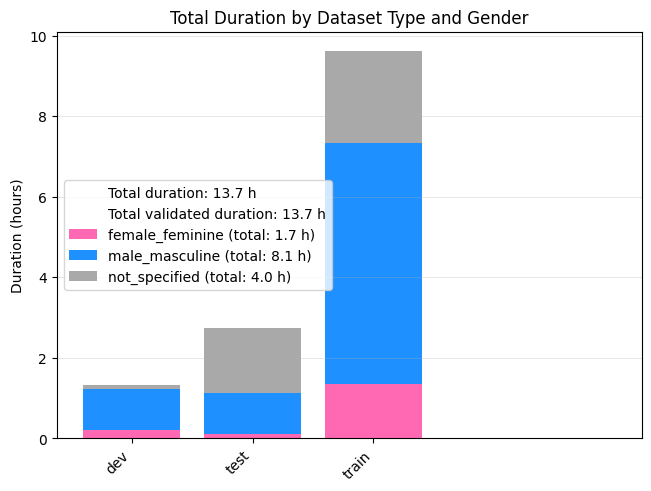

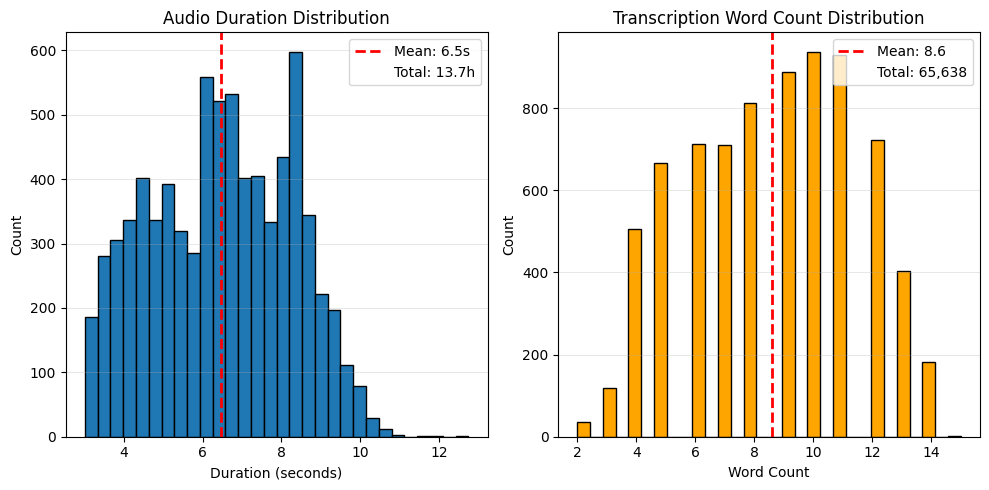

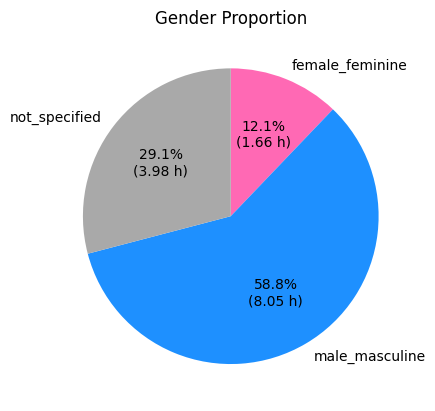


About speakers in final sample:
count                                                  7631
unique                                                 1376
top       30fd02023d452dbd8d83510cf487aabca11a7138c6245b...
freq                                                    206
Name: client_id, dtype: object


In [4]:
from scripts.dataset_plotting import plot_dataset_type_gender_distribution, plot_distribution_graphs, \
    plot_gender_pie_chart

final_sampled_df = pd.read_csv(FINAL_SAMPLED_RECORDINGS_PATH, index_col="id")

plot_dataset_type_gender_distribution(final_sampled_df)
plot_distribution_graphs(final_sampled_df)
plot_gender_pie_chart(final_sampled_df)

print("\nAbout speakers in final sample:")
print(final_sampled_df["client_id"].describe())

In [5]:
train_speakers = set(final_sampled_df[final_sampled_df["type"] == "train"]["client_id"])
val_speakers = set(final_sampled_df[final_sampled_df["type"] == "validation"]["client_id"])
test_speakers = set(final_sampled_df[final_sampled_df["type"] == "test"]["client_id"])

print(f"Overlap Train/Val: {train_speakers.intersection(val_speakers)}")
print(f"Overlap Train/Test: {train_speakers.intersection(test_speakers)}")
print(f"Overlap Val/Test: {val_speakers.intersection(test_speakers)}")

Overlap Train/Val: set()
Overlap Train/Test: set()
Overlap Val/Test: set()
